In [1]:
from typing import cast
import pandas as pd
from config import DATASET_PATH, DIAGNOSIS_PALETTE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
if DATASET_PATH.exists():
    df = pd.read_csv(DATASET_PATH)
else:
    from sklearn.datasets import load_breast_cancer

    data = load_breast_cancer(as_frame=True)
    df = cast(pd.DataFrame, data.frame)
    df.to_csv(DATASET_PATH)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               569 non-null    int64  
 1   mean radius              569 non-null    float64
 2   mean texture             569 non-null    float64
 3   mean perimeter           569 non-null    float64
 4   mean area                569 non-null    float64
 5   mean smoothness          569 non-null    float64
 6   mean compactness         569 non-null    float64
 7   mean concavity           569 non-null    float64
 8   mean concave points      569 non-null    float64
 9   mean symmetry            569 non-null    float64
 10  mean fractal dimension   569 non-null    float64
 11  radius error             569 non-null    float64
 12  texture error            569 non-null    float64
 13  perimeter error          569 non-null    float64
 14  area error               569 non-null

In [4]:
print(f"Dataset has {len(df)} rows and {len(df.columns)} columns")

Dataset has 569 rows and 32 columns


In [5]:
df.columns

Index(['Unnamed: 0', 'mean radius', 'mean texture', 'mean perimeter',
       'mean area', 'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='str')

In [6]:
df.rename(columns={"Unnamed: 0": "patient_id"}, inplace=True)
df.set_index("patient_id", inplace=True)

In [7]:
df.rename(columns={col:col.replace(" ", "_") for col in df.columns}, inplace=True)

In [8]:
df['target'].unique()

array([0, 1])

In [9]:
# 1: sano, 0: malato
df['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [10]:
# trasformazione -> 0: sano, 1: malato
df['target'] = 1 - df['target']
df['target'].value_counts()

target
0    357
1    212
Name: count, dtype: int64

In [11]:
target_mapping = {1: "Malignant", 0: "Benign"}
df['diagnosis'] = df['target'].map(target_mapping)

malignant_patients = df[df['diagnosis'] == "Malignant"]
benign_patients = df[df['diagnosis'] == "Benign"]

print(f"There are {len(malignant_patients)} malignant patients ({len(malignant_patients) / df.shape[0] * 100:.2f}%), "
      f"and {len(benign_patients)} benign patients ({len(benign_patients) / df.shape[0] * 100:.2f}%)")

There are 212 malignant patients (37.26%), and 357 benign patients (62.74%)


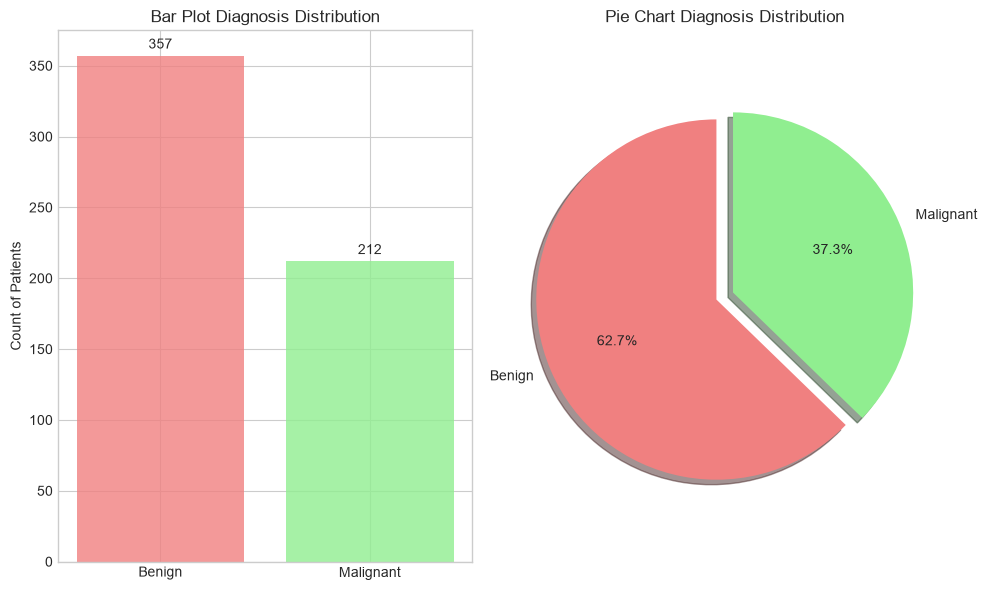

In [12]:
# bar plot e pie chart distribuzione classi
diagnosis_counts = df['diagnosis'].value_counts()
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
bars = plt.bar(diagnosis_counts.index, diagnosis_counts.values,
               color=DIAGNOSIS_PALETTE.values(), alpha=0.8)
plt.title('Bar Plot Diagnosis Distribution')
plt.ylabel('Count of Patients')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 3,
             f'{height}', ha='center', va='bottom')

plt.subplot(1, 2, 2)
explode = (0.05, 0.05)
plt.pie(diagnosis_counts.values, labels=diagnosis_counts.index, colors=DIAGNOSIS_PALETTE.values(),
        autopct='%1.1f%%', startangle=90, explode=explode, shadow=True)
plt.title('Pie Chart Diagnosis Distribution')
plt.axis('equal')
plt.tight_layout()
plt.show()

In [13]:
dimensions = df.filter(like="mean_").columns.to_list()
dimensions = [dimension.replace("mean_", "") for dimension in dimensions]
dimensions

['radius',
 'texture',
 'perimeter',
 'area',
 'smoothness',
 'compactness',
 'concavity',
 'concave_points',
 'symmetry',
 'fractal_dimension']

In [14]:
features = pd.Index([feature for feature in
            df.select_dtypes(include="number").columns.to_list()
            if feature != "target"])

mean_features = [feature for feature in features if feature.startswith("mean_")]
worst_features = [feature for feature in features if feature.startswith("worst_")]
error_features = [feature for feature in features if feature.endswith("_error")]

features_groups = {
    "mean": mean_features,
    "worst": worst_features,
    "error": error_features
}

In [15]:
mean_dimensions = [feature.replace("mean_", "") for feature in mean_features]
worst_dimensions = [feature.replace("worst_", "") for feature in worst_features]
error_dimensions = [feature.replace("_error", "") for feature in error_features]

set(mean_dimensions) == set(worst_dimensions) == set(error_dimensions)

True

In [16]:
df

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,...,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target,diagnosis
patient_id,,,,,,,,,,,,,,,,,,,,,
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,1,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,1,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,1,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,1,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,1,Malignant
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,1,Malignant
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,1,Malignant
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,1,Malignant


In [17]:
def plot_correlation_heatmap(corr_matrix: pd.DataFrame, row_tick: str, col_tick: str) -> None:
    plt.figure(figsize=(16, 16))
    sns.set_style("white")
    row_features = features_groups[row_tick]
    col_features = features_groups[col_tick]
    sns.heatmap(data=corr_matrix.loc[row_features, col_features], square=True, annot=True, fmt=".2f", cmap="coolwarm")
    title = f"Correlation Heatmap {row_tick.capitalize()} vs {col_tick.capitalize()}"
    plt.title(title, fontsize=16)
    plt.show()

In [18]:
import itertools

combinations = list(itertools.combinations(features_groups.keys(), 2))
combinations

[('mean', 'worst'), ('mean', 'error'), ('worst', 'error')]

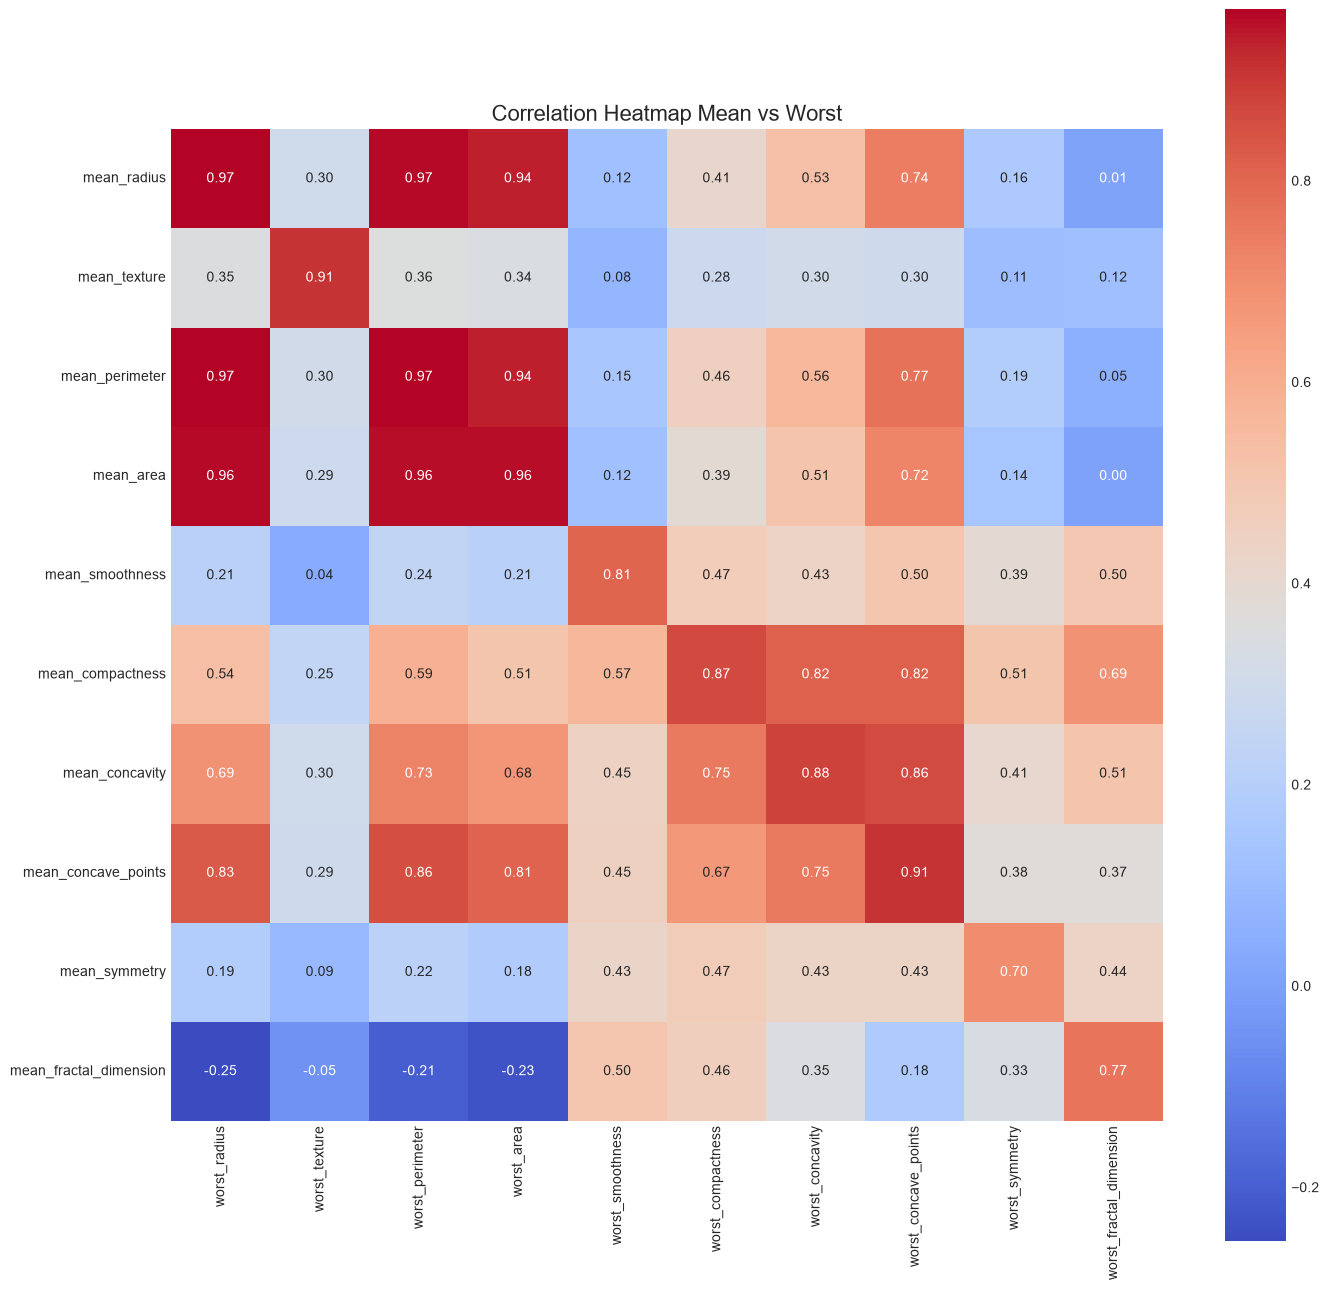

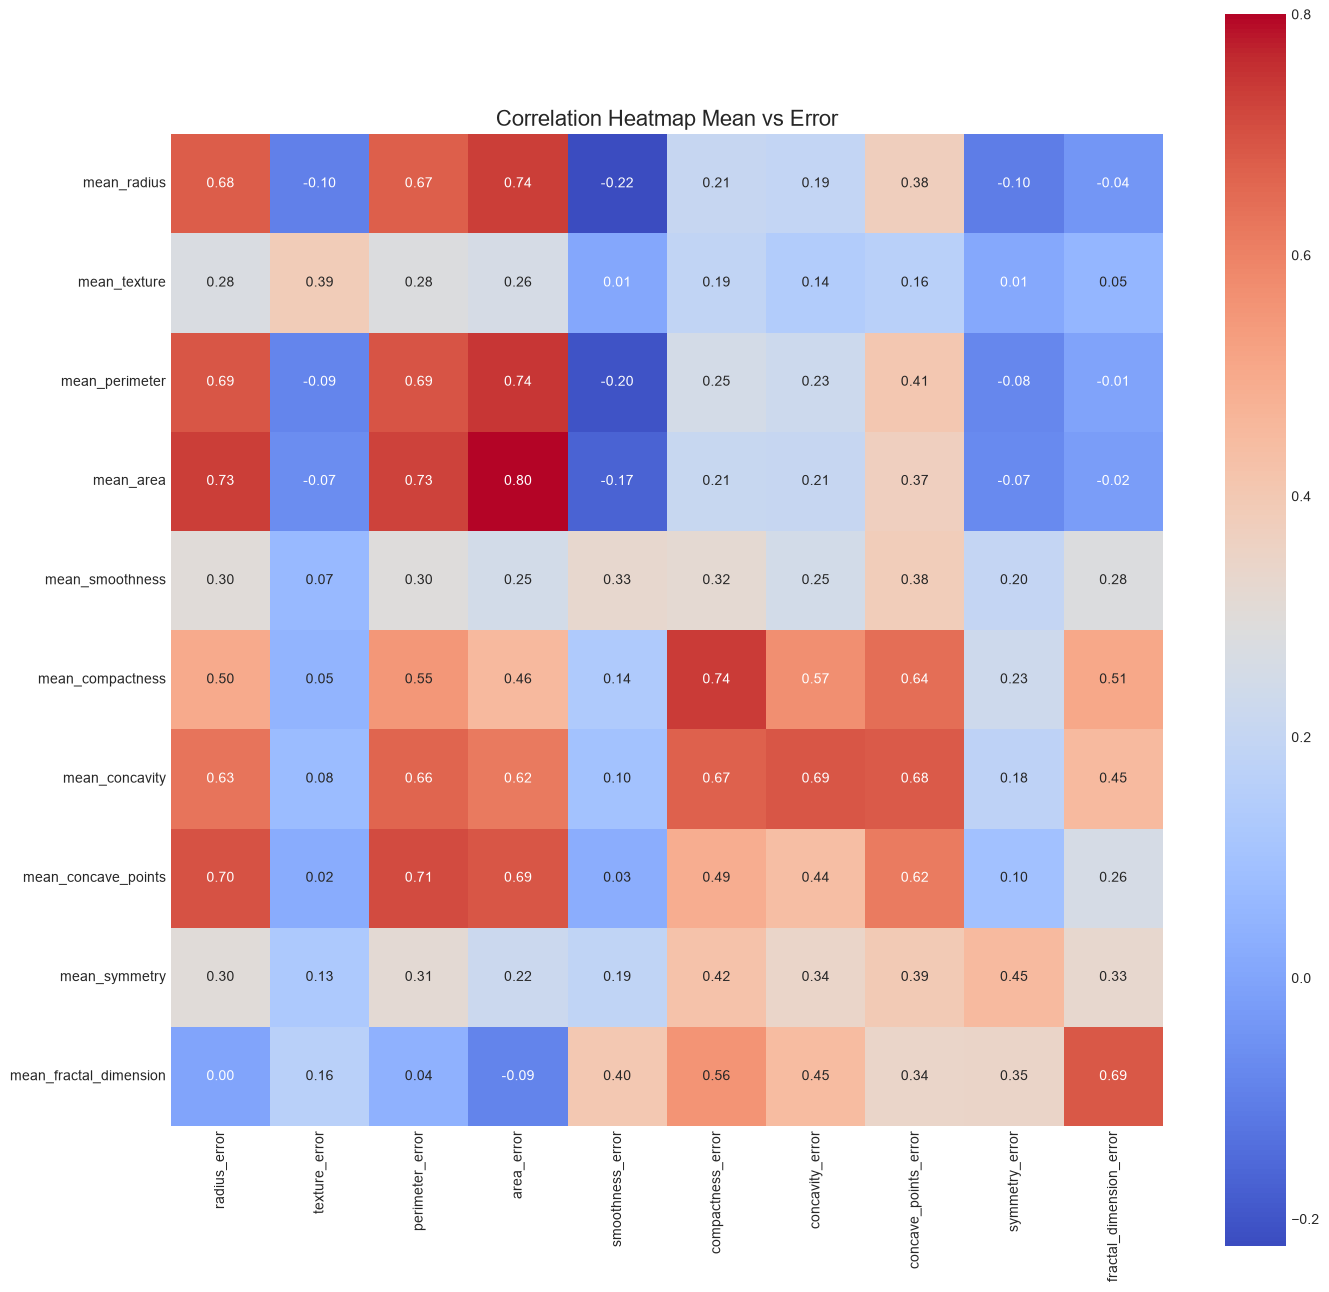

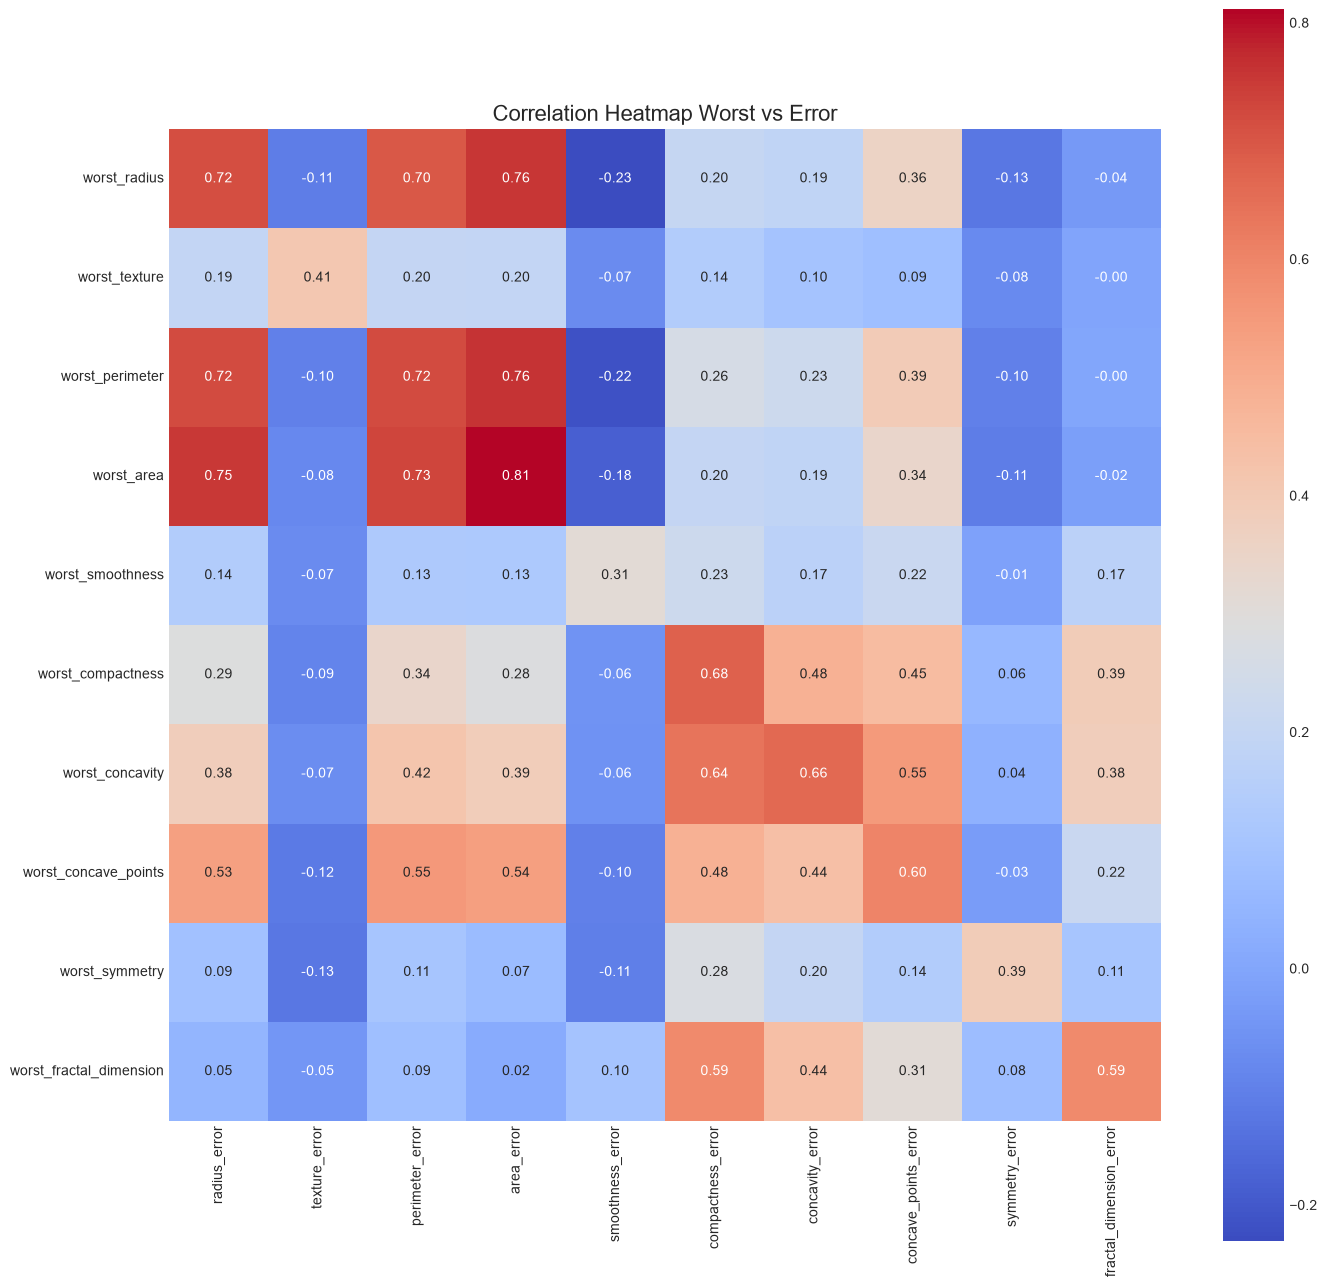

In [19]:
corr = df[features].corr()

for row_tick, col_tick in combinations:
    plot_correlation_heatmap(corr, row_tick, col_tick)

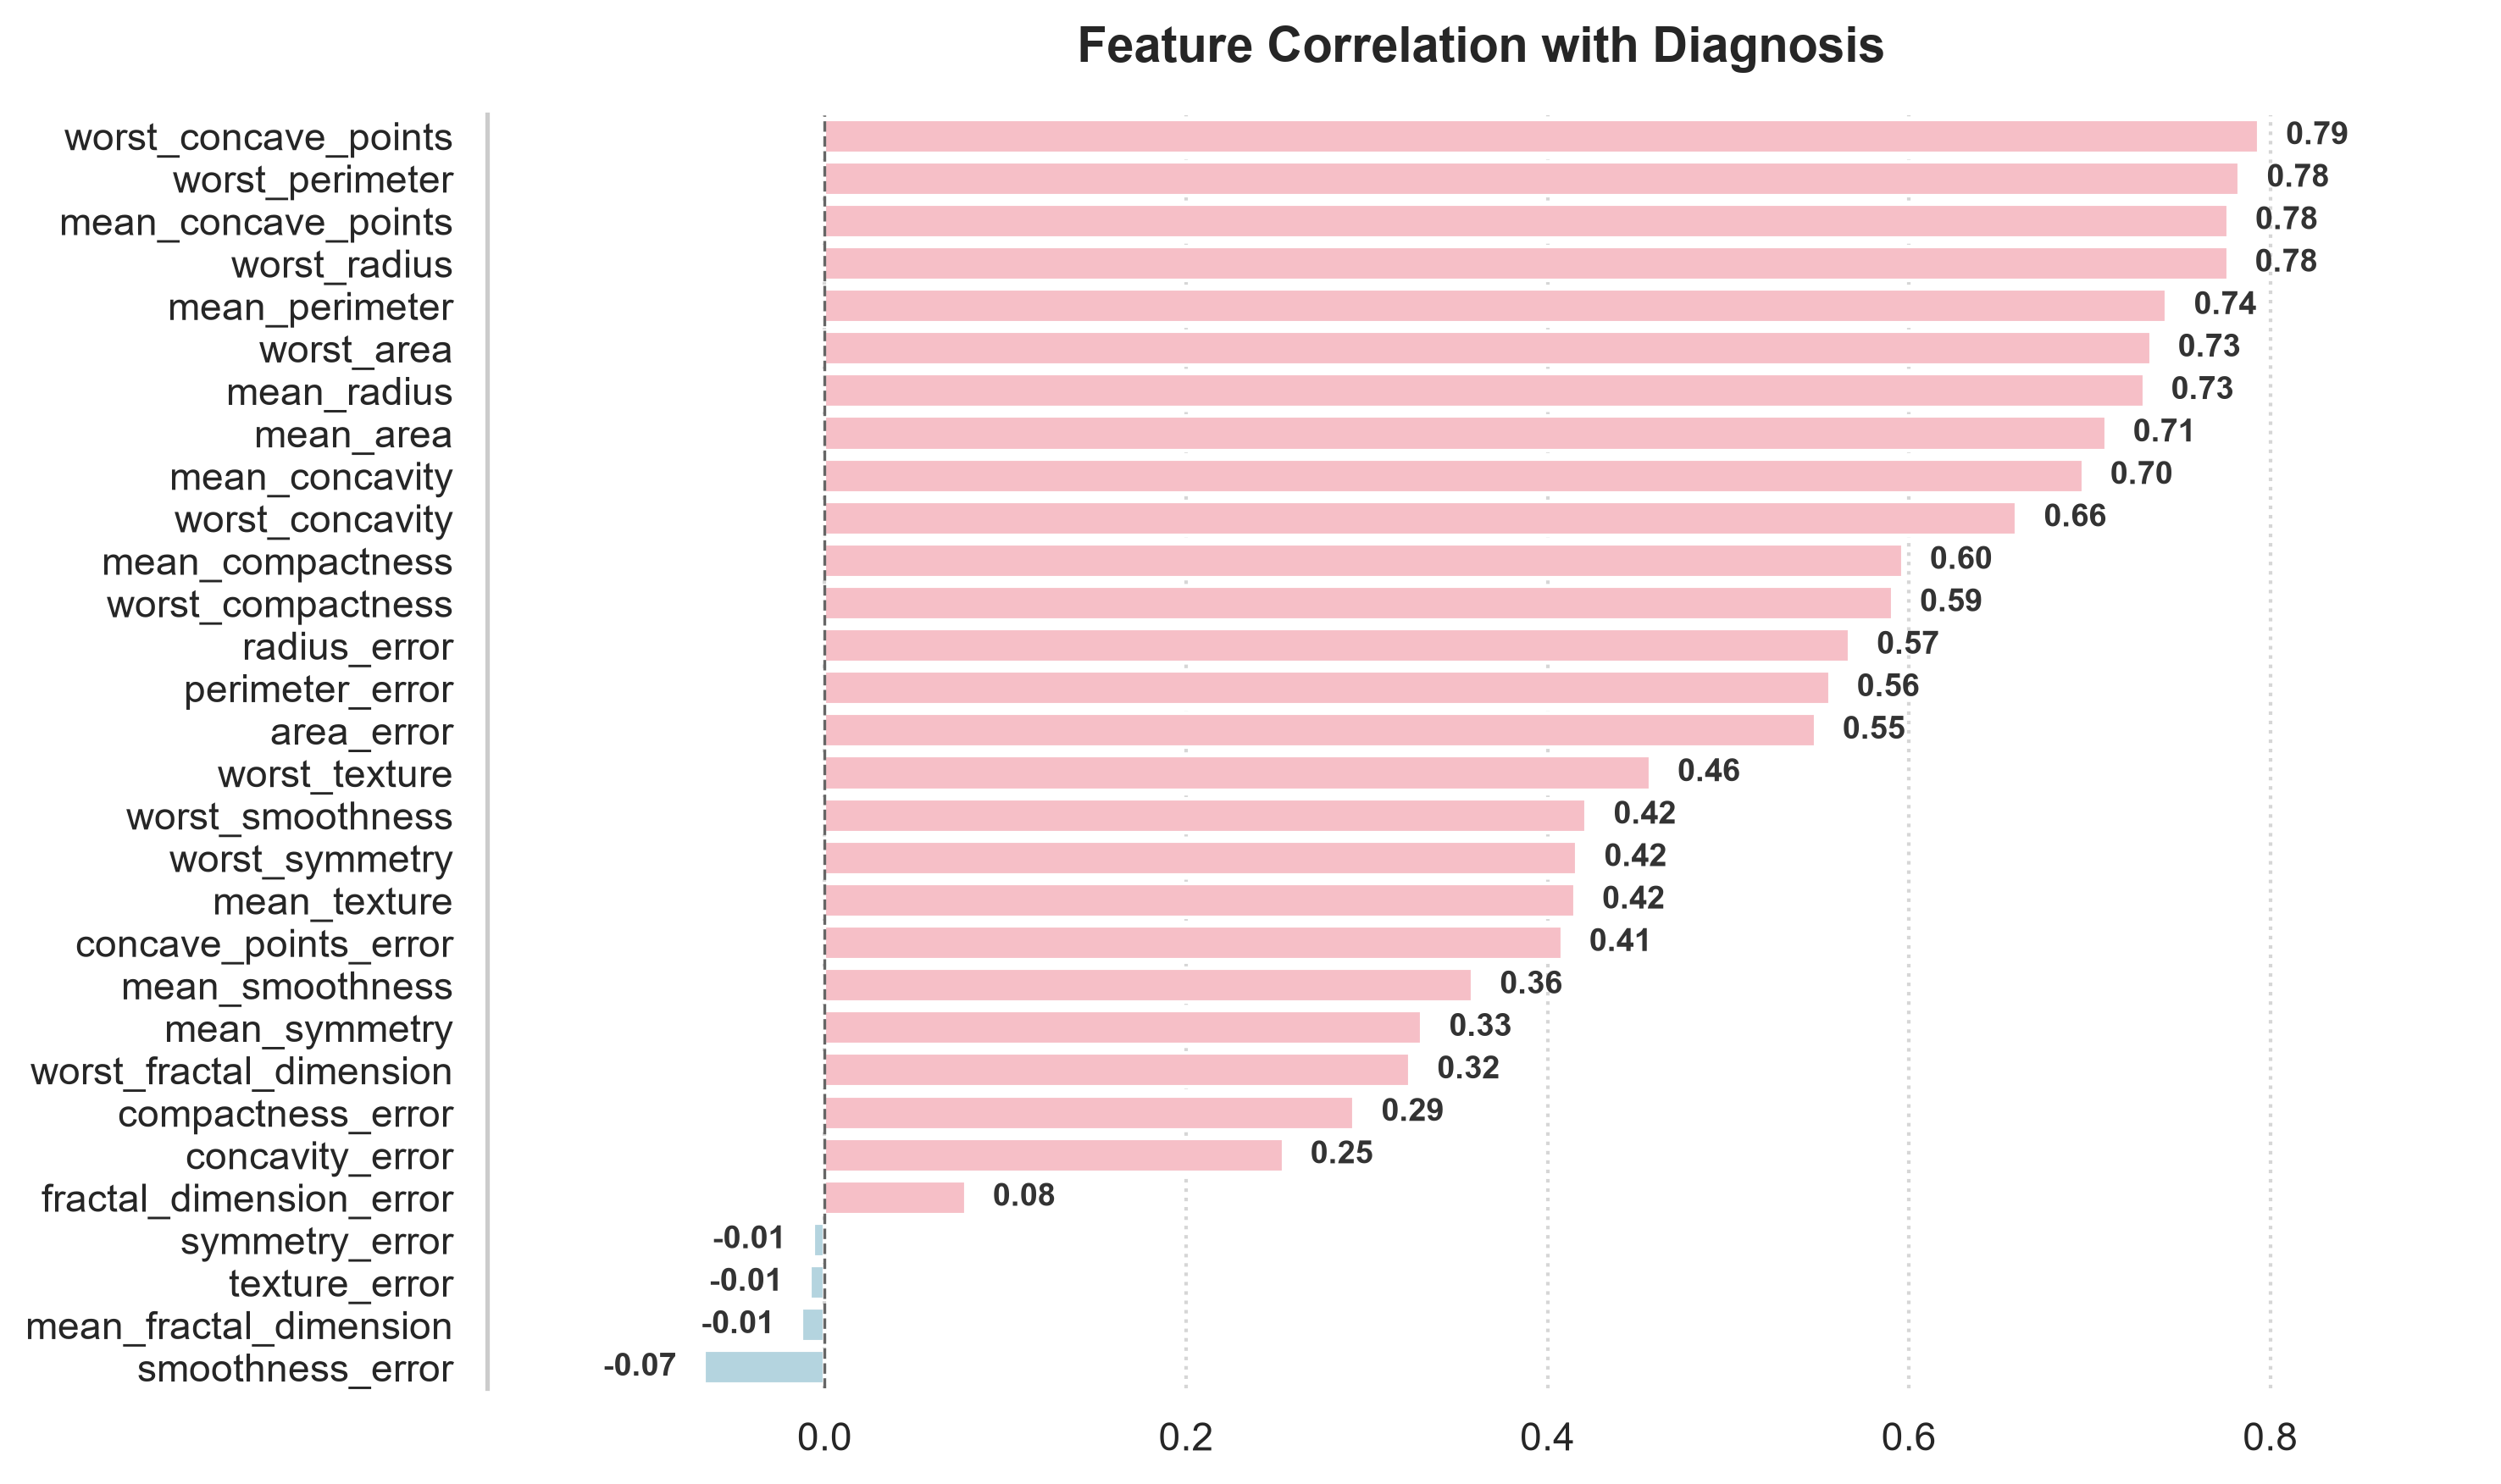

In [20]:
target_corr = df[features].corrwith(df["target"]).sort_values(ascending=False)

plt.figure(figsize=(10, 6), dpi=300)
sns.set_theme(style="white")

colors = ["lightpink" if val > 0 else "lightblue" for val in target_corr.values]

ax = sns.barplot(
    x=target_corr.values, y=target_corr.index, palette=colors, hue=target_corr.index, legend=False
)

for p in ax.patches:
    val = p.get_width()
    offset = 0.015 if val >= 0 else -0.015
    ha = "left" if val >= 0 else "right"
    ax.annotate(
        f"{val:.2f}",
        (val + offset, p.get_y() + p.get_height() / 2),
        ha=ha,
        va="center",
        fontsize=9,
        fontweight="bold",
        color="#333333",
    )

ax.axvline(0, color="#666666", linewidth=0.8, linestyle="--")
ax.set_xlim(target_corr.min() - 0.12, target_corr.max() + 0.12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_color("#cccccc")

plt.ylabel("")
plt.title(
    "Feature Correlation with Diagnosis",
    fontsize=14,
    fontweight="bold",
    pad=15,
    loc="center",
)
plt.grid(axis="x", linestyle=":", alpha=0.6, color="#bbbbbb")

plt.tight_layout()
plt.show()

In [21]:
scaler = StandardScaler().set_output(transform="pandas")
df_scaled = scaler.fit_transform(df[features])
df_scaled["diagnosis"] = df["diagnosis"]

df_scaled.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,...,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,diagnosis
patient_id,,,,,,,,,,,,,,,,,,,,,
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015,Malignant
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190,Malignant
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391,Malignant
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010,Malignant
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100,Malignant


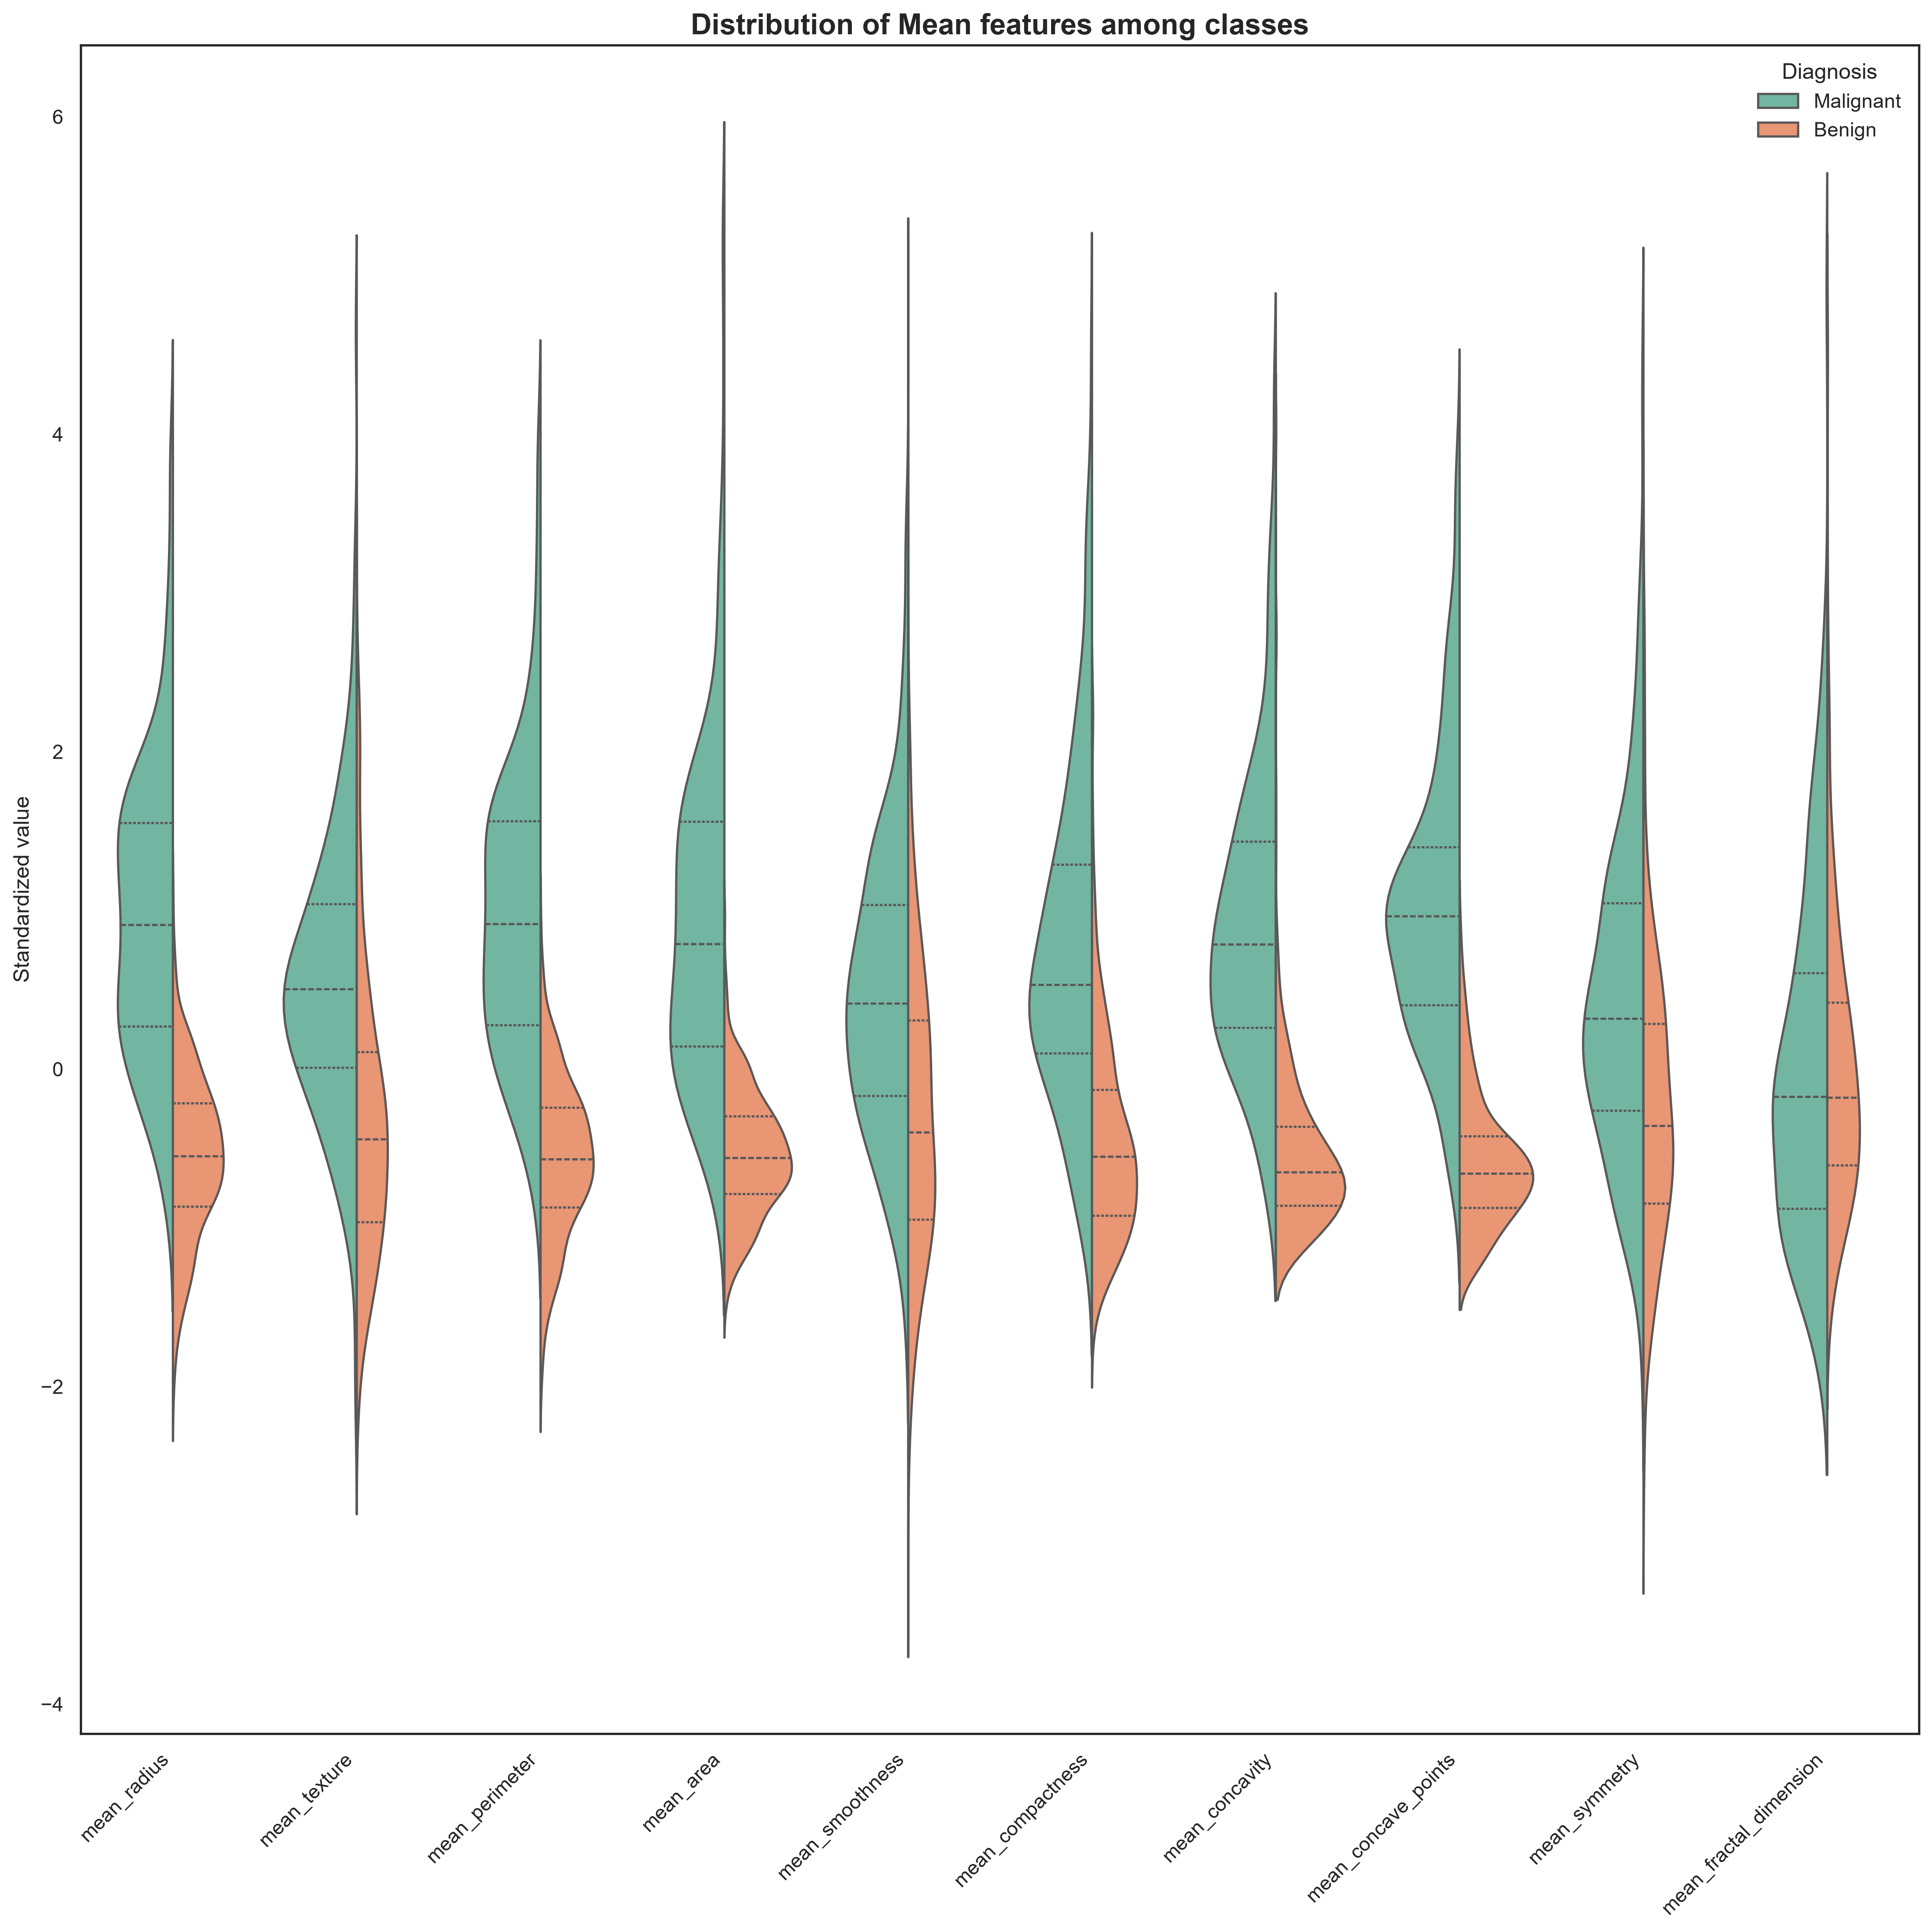

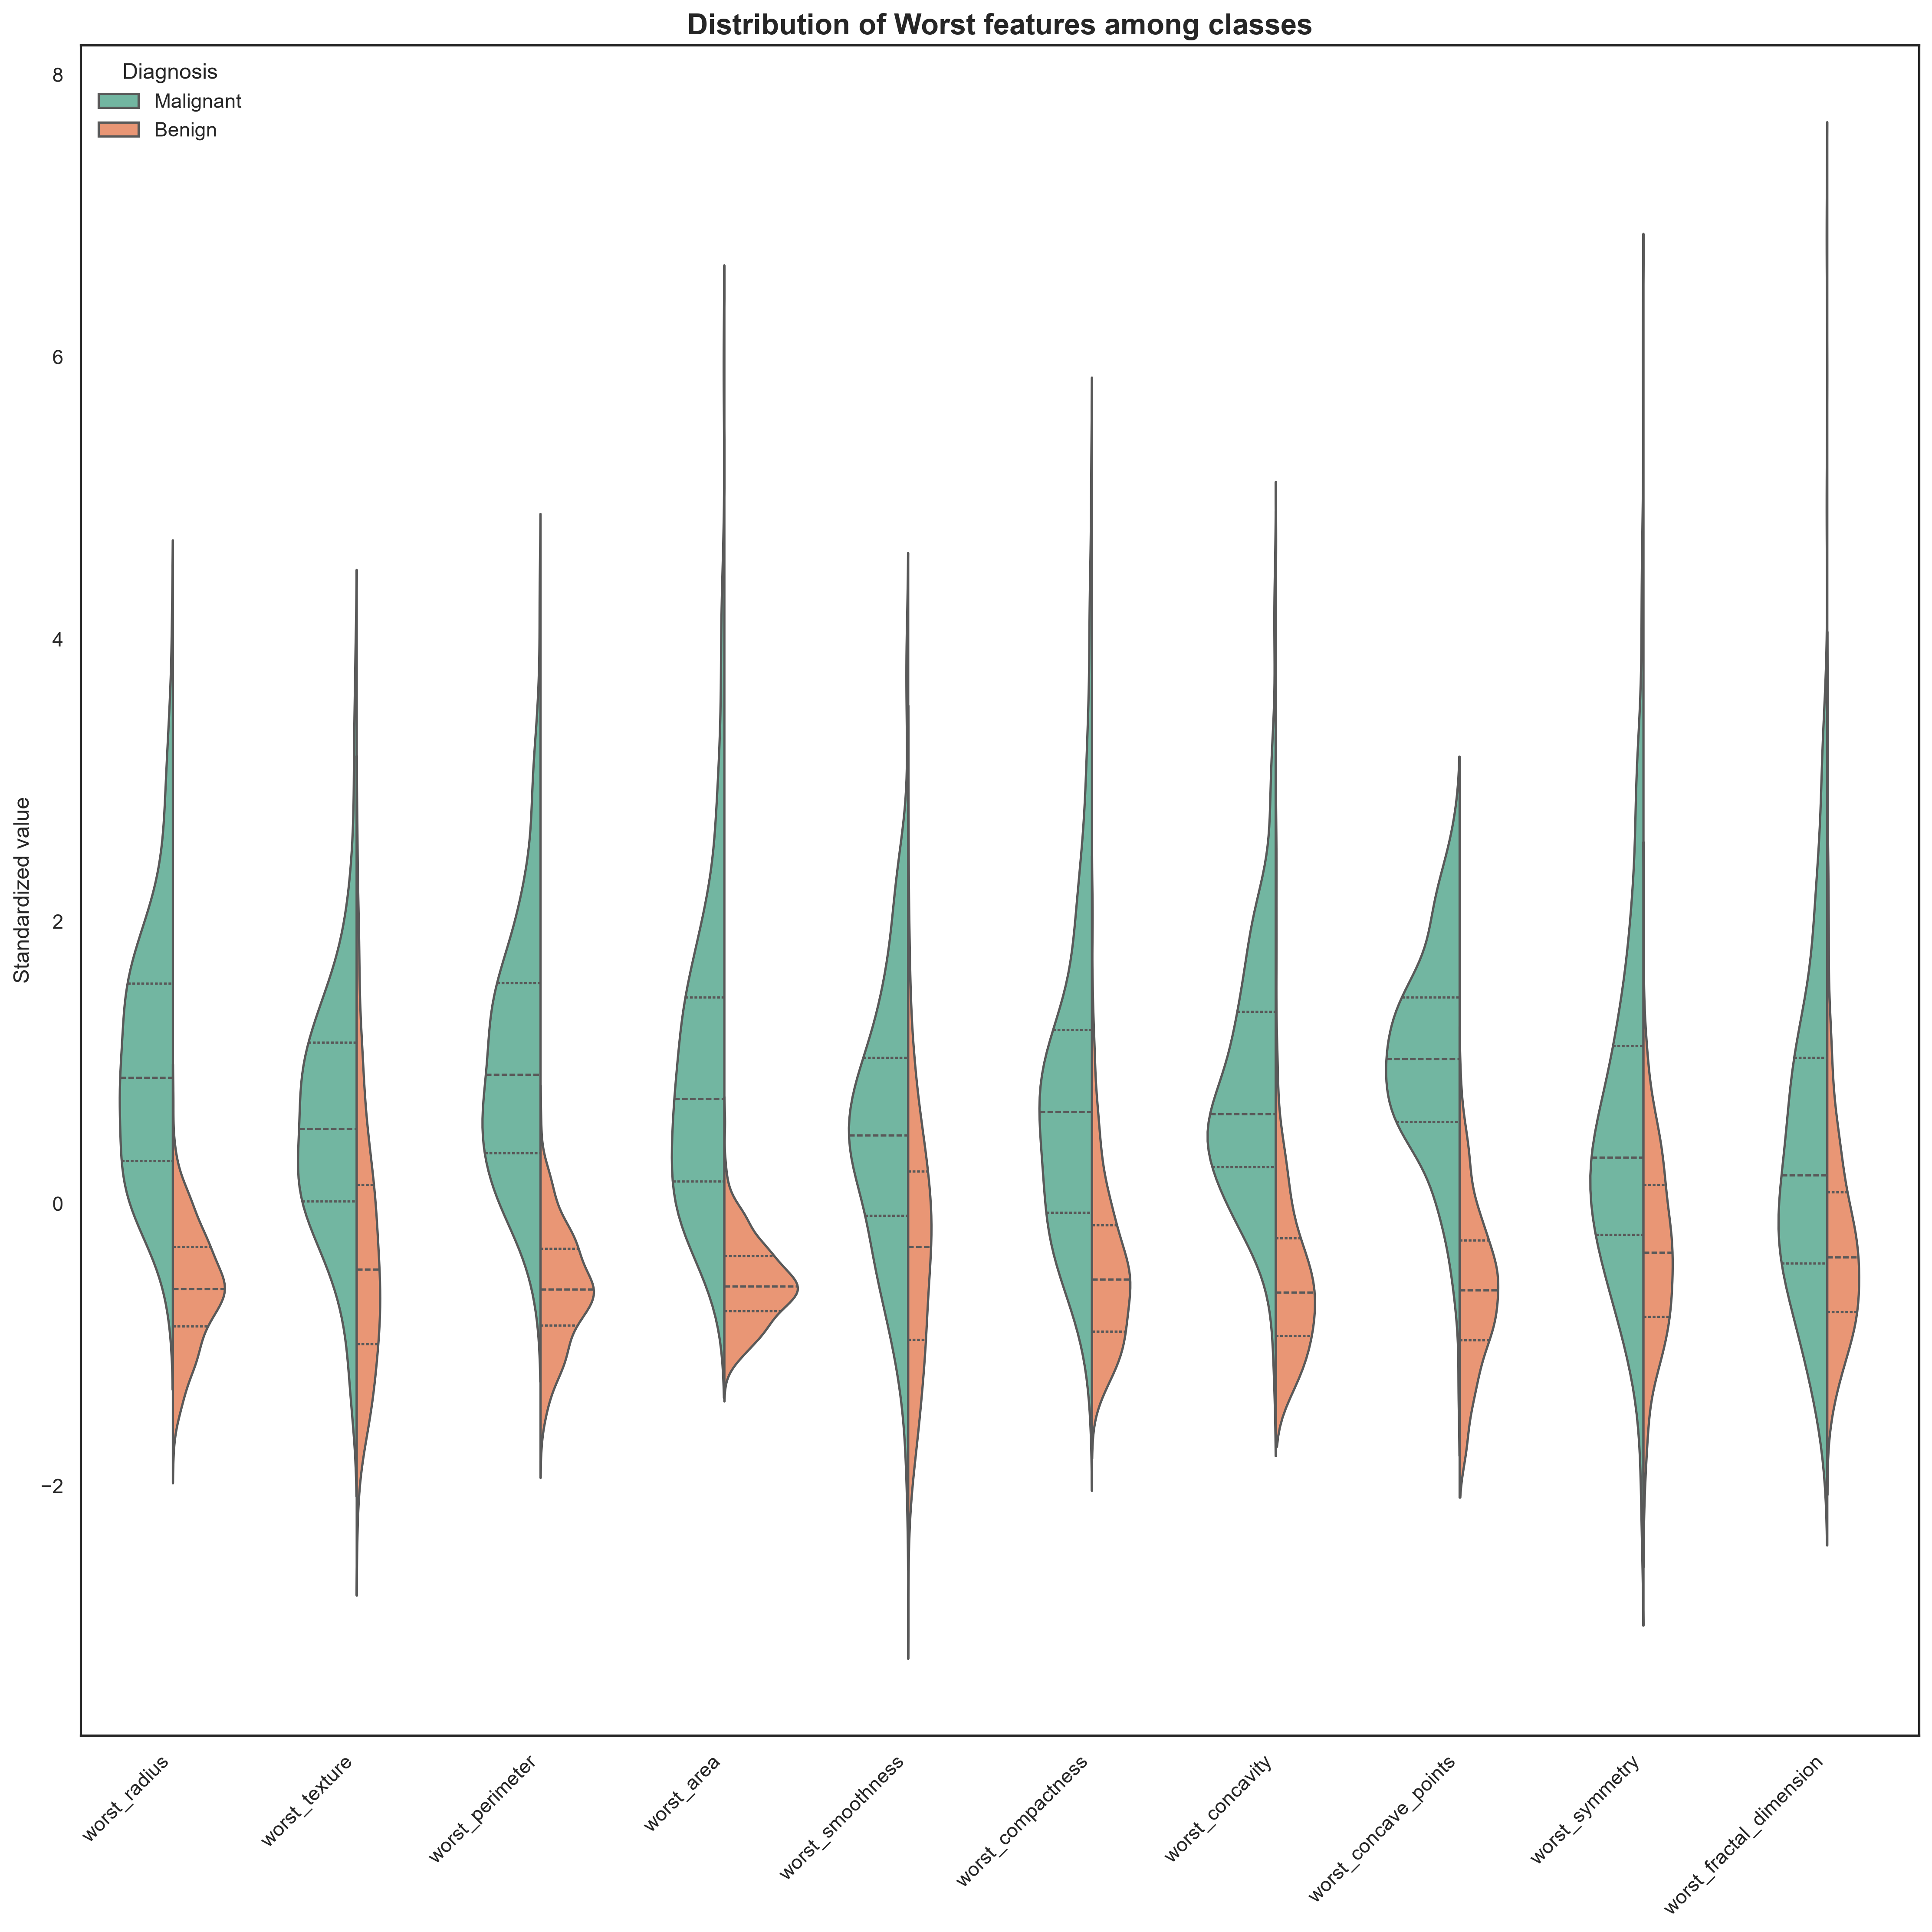

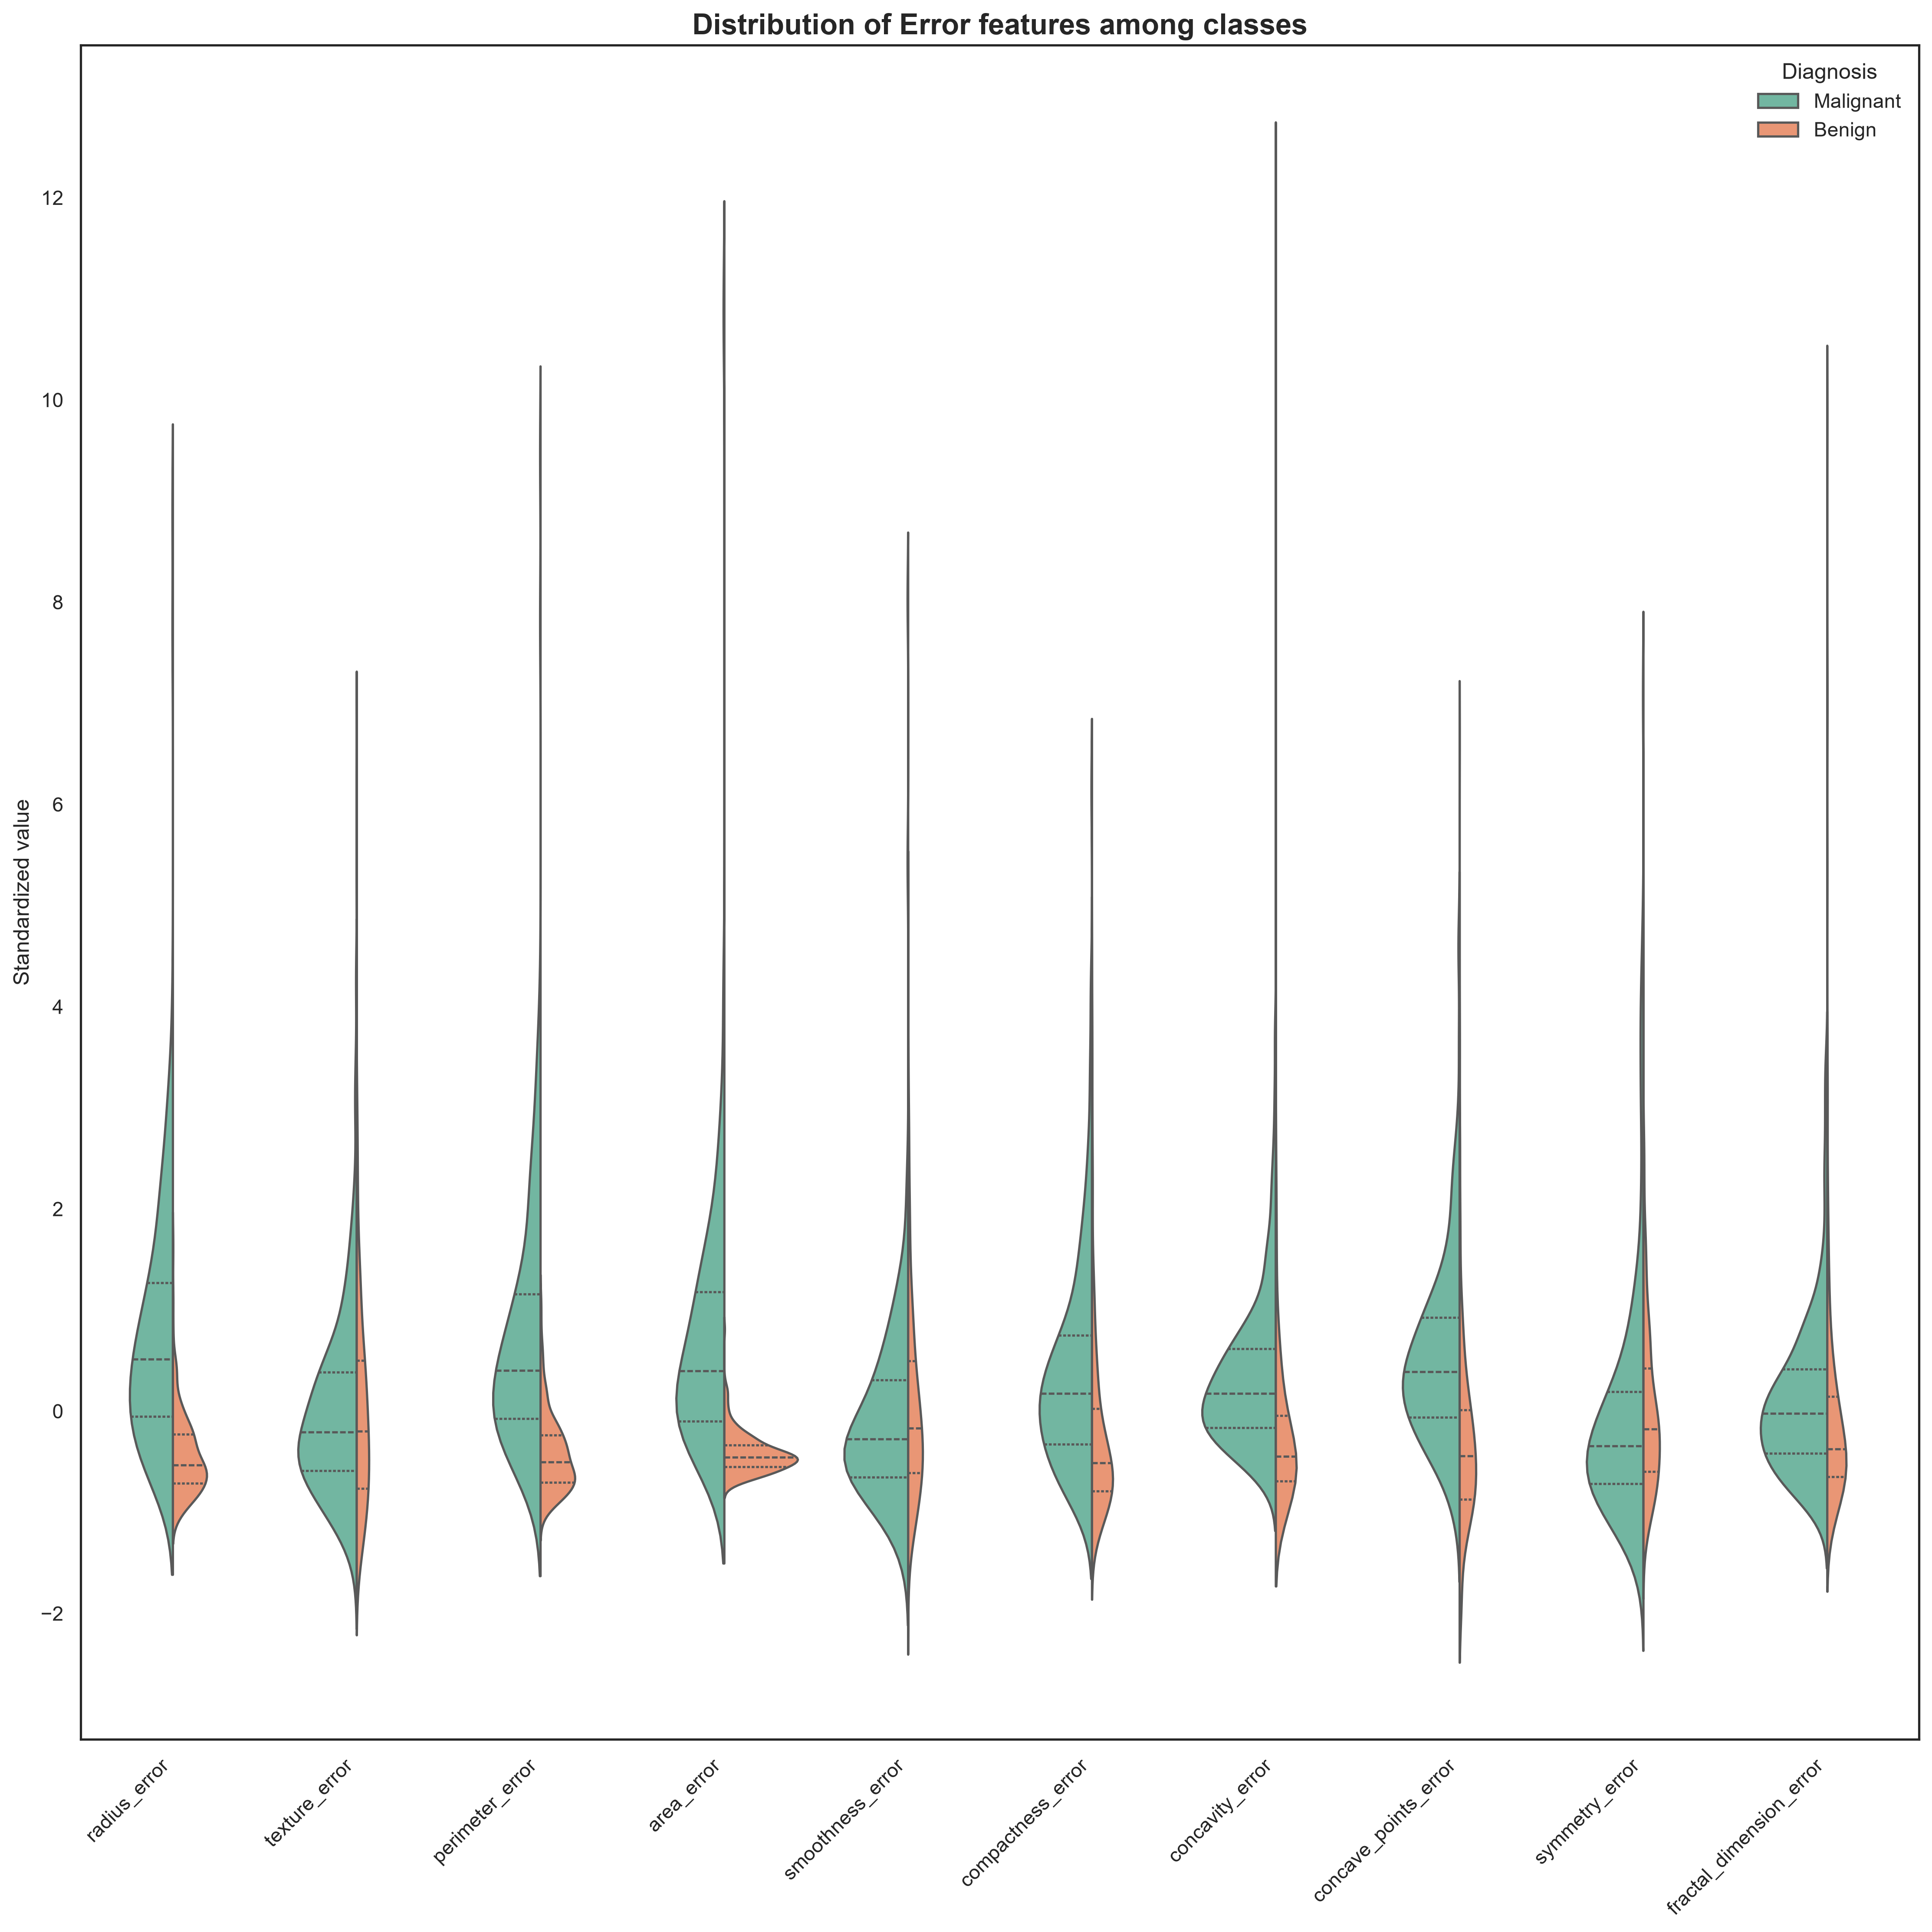

In [22]:
def plot_violinplot(df: pd.DataFrame, tick: str) -> None:
    features = features_groups[tick]
    data = df[['diagnosis'] + features].copy()
    df_melt = pd.melt(frame=data, id_vars=['diagnosis'], value_vars=features,
                       var_name='variable', value_name='value')

    fig, ax = plt.subplots(1, 1, figsize=(15, 15), dpi=300)
    sns.violinplot(
        x="variable", y="value", hue="diagnosis",
        data=df_melt, split=True, inner="quart",
        palette='Set2', ax=ax
    )
    ax.set_title(f'Distribution of {tick.capitalize()} features among classes', fontsize=16, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Standardized value')
    plt.xticks(rotation=45, ha='right')
    ax.legend(title='Diagnosis')
    plt.tight_layout()
    plt.show()

for tick in features_groups.keys():
    plot_violinplot(df_scaled, tick=tick)

In [23]:
df_scaled = df_scaled.drop(columns=["diagnosis"])

pca = PCA()
df_pca = pca.fit_transform(df_scaled)
explained = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained)

variance_threshold = 0.90
n_components = np.argmax(cumulative_variance >= variance_threshold) + 1
total_var = cumulative_variance[n_components - 1]

print(f"It's possible to achieve {total_var * 100:.2f}% variance explained with {n_components} components")

It's possible to achieve 91.01% variance explained with 7 components


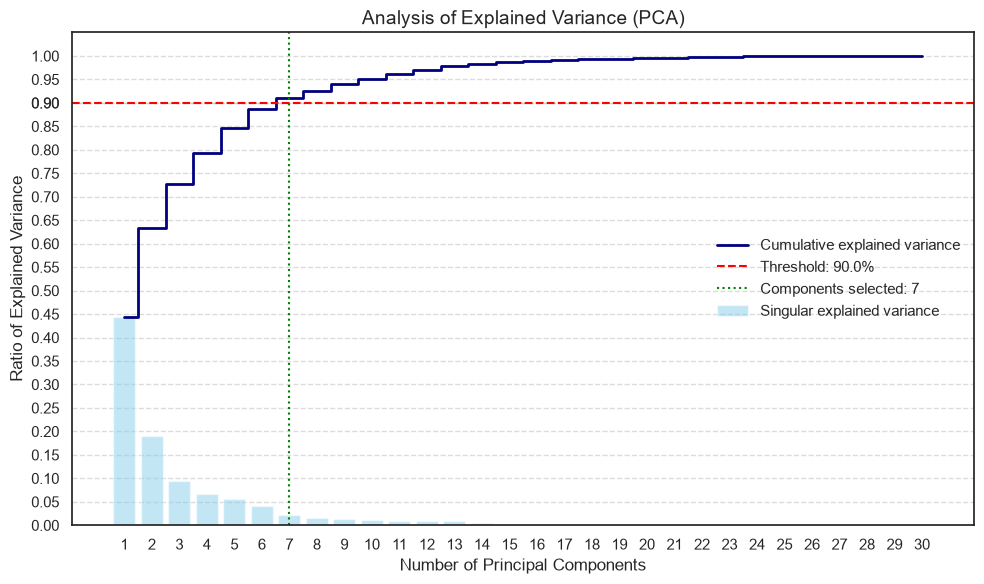

In [24]:
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained) + 1), explained, alpha=0.5, align='center',
        label='Singular explained variance', color='skyblue')
plt.step(range(1, len(explained) + 1), np.cumsum(explained), where='mid',
         label='Cumulative explained variance', color='navy', linewidth=2)
plt.axhline(y=variance_threshold, color='red', linestyle='--',
            label=f'Threshold: {variance_threshold*100}%')
plt.axvline(x=n_components, color='green', linestyle=':',
            label=f'Components selected: {n_components}')
plt.title('Analysis of Explained Variance (PCA)', fontsize=14)
plt.xlabel('Number of Principal Components', fontsize=12)
plt.ylabel('Ratio of Explained Variance', fontsize=12)
plt.xticks(range(1, len(explained) + 1))
ticks = list(np.arange(0, 1.01, 0.05)) + [variance_threshold]
plt.yticks(ticks)
plt.legend(loc='center right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

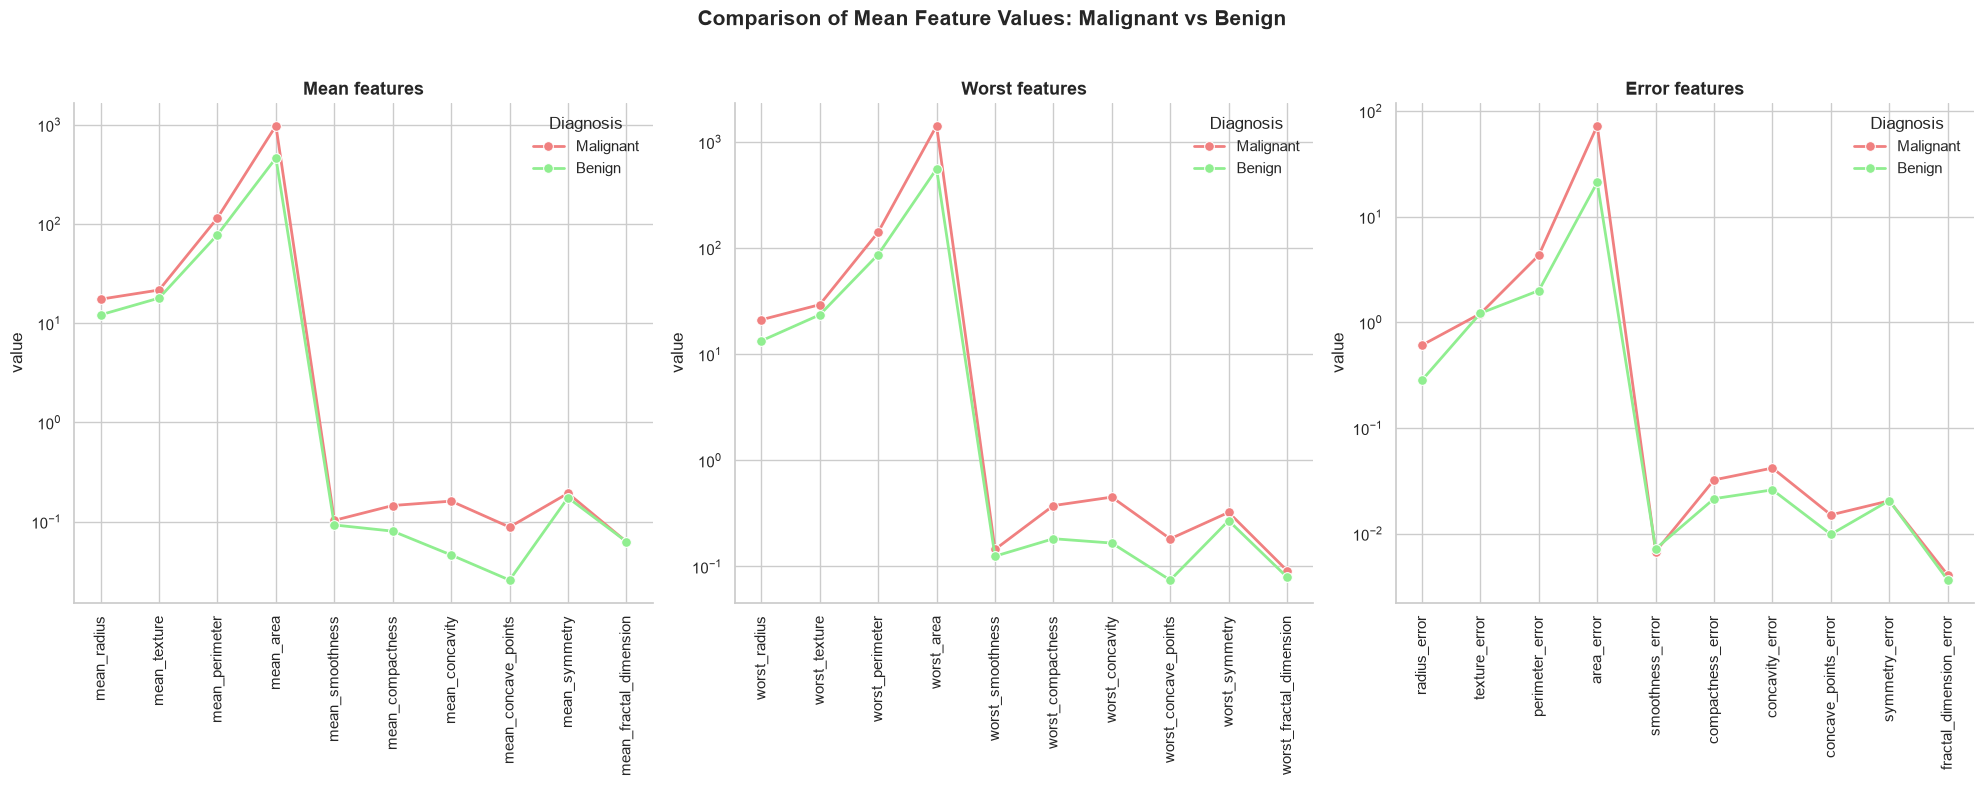

In [25]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
axes_flatten = axes.flatten()

for i, tick in enumerate(features_groups):
    ax = axes_flatten[i]
    features_group = features_groups[tick]
    comparison_df = pd.DataFrame({
        "features": features_group,
        target_mapping[1]: df.query("target == 1")[features_group].mean().values,
        target_mapping[0]: df.query("target == 0")[features_group].mean().values,
    })

    comparison_df_melted = comparison_df.melt(id_vars="features", var_name="diagnosis", value_name="value")

    sns.lineplot(
        data=comparison_df_melted,
        x="features", y="value", hue="diagnosis",
        palette=DIAGNOSIS_PALETTE, marker="o", linewidth=2, markersize=7,
        ax=ax,
    )

    ax.set_title(f"{tick.capitalize()} features", fontsize=13, fontweight="bold")
    ax.set_xlabel("")

    ax.set_yscale("log")
    ax.tick_params(axis="x", labelrotation=90)
    ax.legend(title="Diagnosis", frameon=False)
    sns.despine(ax=ax)

fig.suptitle(f"Comparison of Mean Feature Values: {target_mapping[1]} vs {target_mapping[0]}", fontsize=15, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.96])

plt.show(fig)
plt.close(fig)

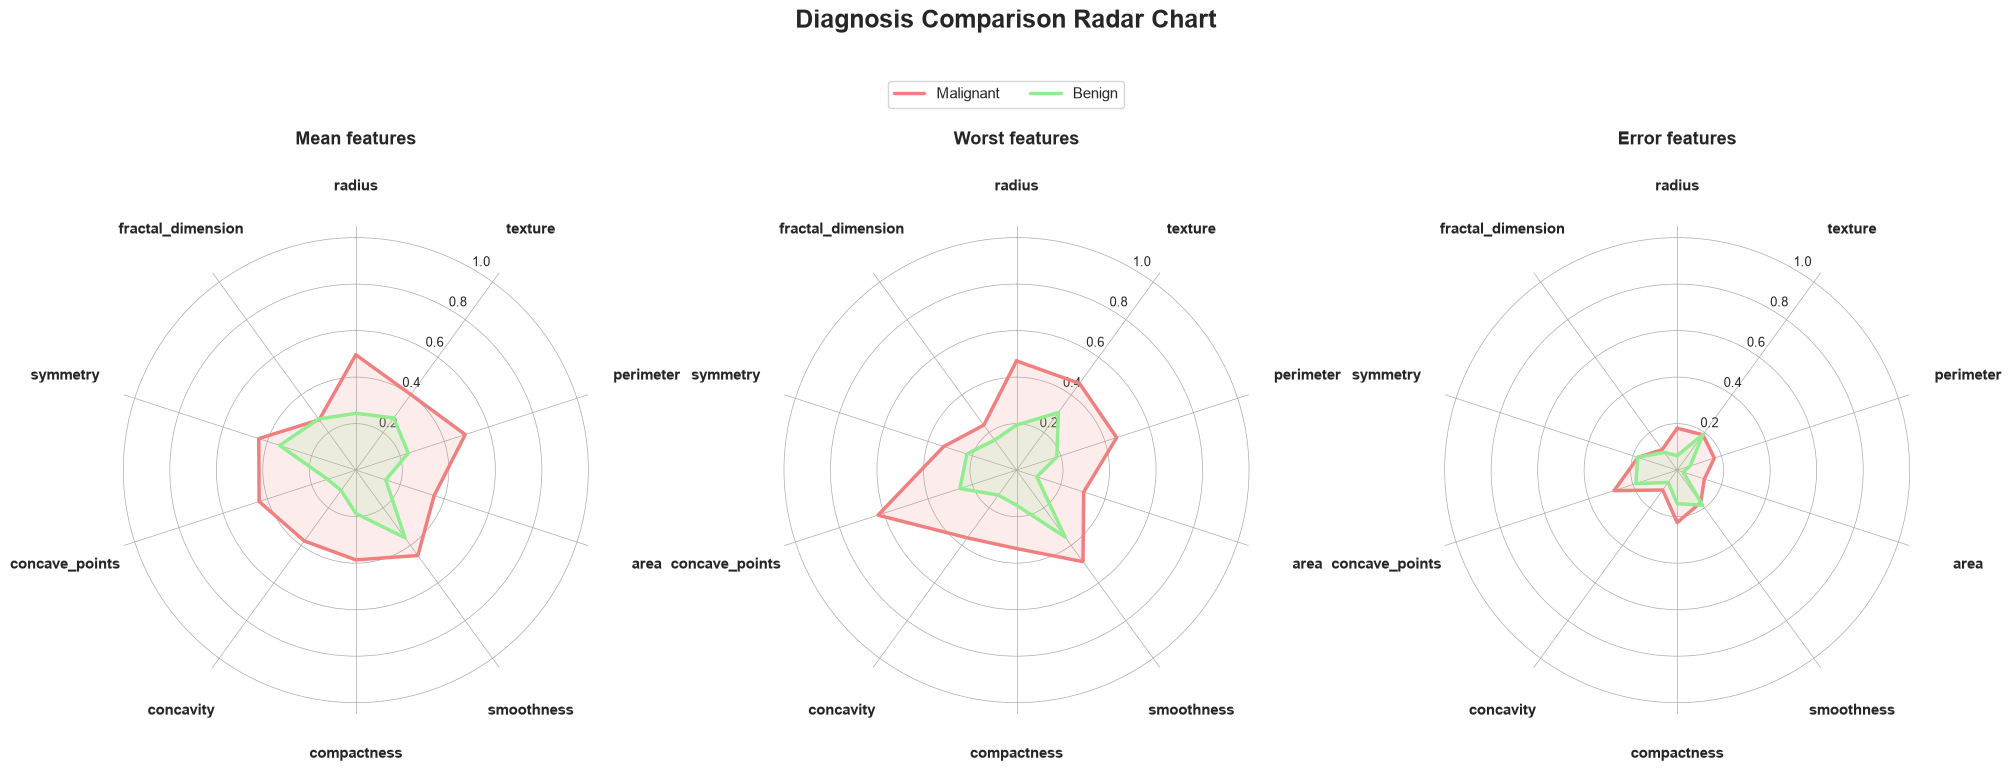

In [26]:
from typing import cast
from math import pi

df_norm = df.copy()

fig, ax = plt.subplots(figsize=(20, 8), nrows=1, ncols=3, subplot_kw=dict(polar=True))
axes_flatten = ax.flatten()
fig.subplots_adjust(wspace=0.75)

for i, tick in enumerate(features_groups):
    ax = axes_flatten[i]
    feature_group = features_groups[tick]

    for col in feature_group:
        min_val = float(df[col].min())
        max_val = float(df[col].max())
        df_norm[col] = (df[col] - min_val) / (max_val - min_val + 1e-9)

    N = len(feature_group)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    malignant_values = df_norm.query("target == 1")[feature_group].mean().values.tolist()
    malignant_values += malignant_values[:1] 

    benign_values = df_norm.query("target == 0")[feature_group].mean().values.tolist()
    benign_values += benign_values[:1]  

    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)

    ax.plot(
        angles, malignant_values, "-",
        label="Malignant", linewidth=2.5,
        color=DIAGNOSIS_PALETTE.get("Malignant")
    )
    ax.fill(angles, malignant_values, alpha=0.15, color=DIAGNOSIS_PALETTE.get("Malignant"))

    ax.plot(
        angles, benign_values, "-",
        label="Benign", linewidth=2.5,
        color=DIAGNOSIS_PALETTE.get("Benign")
    )
    ax.fill(angles, benign_values, alpha=0.15, color=DIAGNOSIS_PALETTE.get("Benign"))

    ax.set_ylim(0, 1.05)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], size=9)
    ax.set_rlabel_position(30)
    ax.spines['polar'].set_visible(False)
    ax.grid(color='#AAAAAA', linestyle='-', linewidth=0.5)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([], size=11, weight='bold')

    PAD_BASE = 1.22
    PAD_EXTRA = 0.10

    for angle, label_text in zip(angles[:-1], dimensions):
        r_label = float(PAD_BASE + PAD_EXTRA * abs(np.sin(angle)))
        ax.text(
            x=angle, y=r_label, s=label_text,
            ha='center', va='center',
            fontsize=11, fontweight='bold',
            transform=ax.transData
        )

    ax.set_title(f"{tick.capitalize()} features", fontsize=13, fontweight="bold", y=1.15)

handles, labels = axes_flatten[0].get_legend_handles_labels()
fig.suptitle('Diagnosis Comparison Radar Chart', size=18, weight='bold', y=1.05)
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.97), ncol=2, frameon=True, fontsize=11)
fig.tight_layout()
plt.show()

In [27]:
from sklearn.ensemble import IsolationForest

contamination_rate = 0.02

isolation_forest = IsolationForest(
    n_estimators=100,
    contamination=contamination_rate,
    random_state=42
)

isolation_predictions = isolation_forest.fit_predict(df_scaled)
isolation_scores = -isolation_forest.score_samples(df_scaled)
threshold_score = np.percentile(isolation_scores, (1 - contamination_rate) * 100)

print(f"Total samples: {len(df_scaled)}")
print(f"Inliers (isolation_prediction == 1): {(isolation_predictions == 1).sum()}")
print(f"Outliers (isolation_prediction == -1): {(isolation_predictions == -1).sum()}")
print(f"Threshold score to {(1 - contamination_rate) * 100}%: {threshold_score:.4f}\n")

Total samples: 569
Inliers (isolation_prediction == 1): 557
Outliers (isolation_prediction == -1): 12
Threshold score to 98.0%: 0.5767



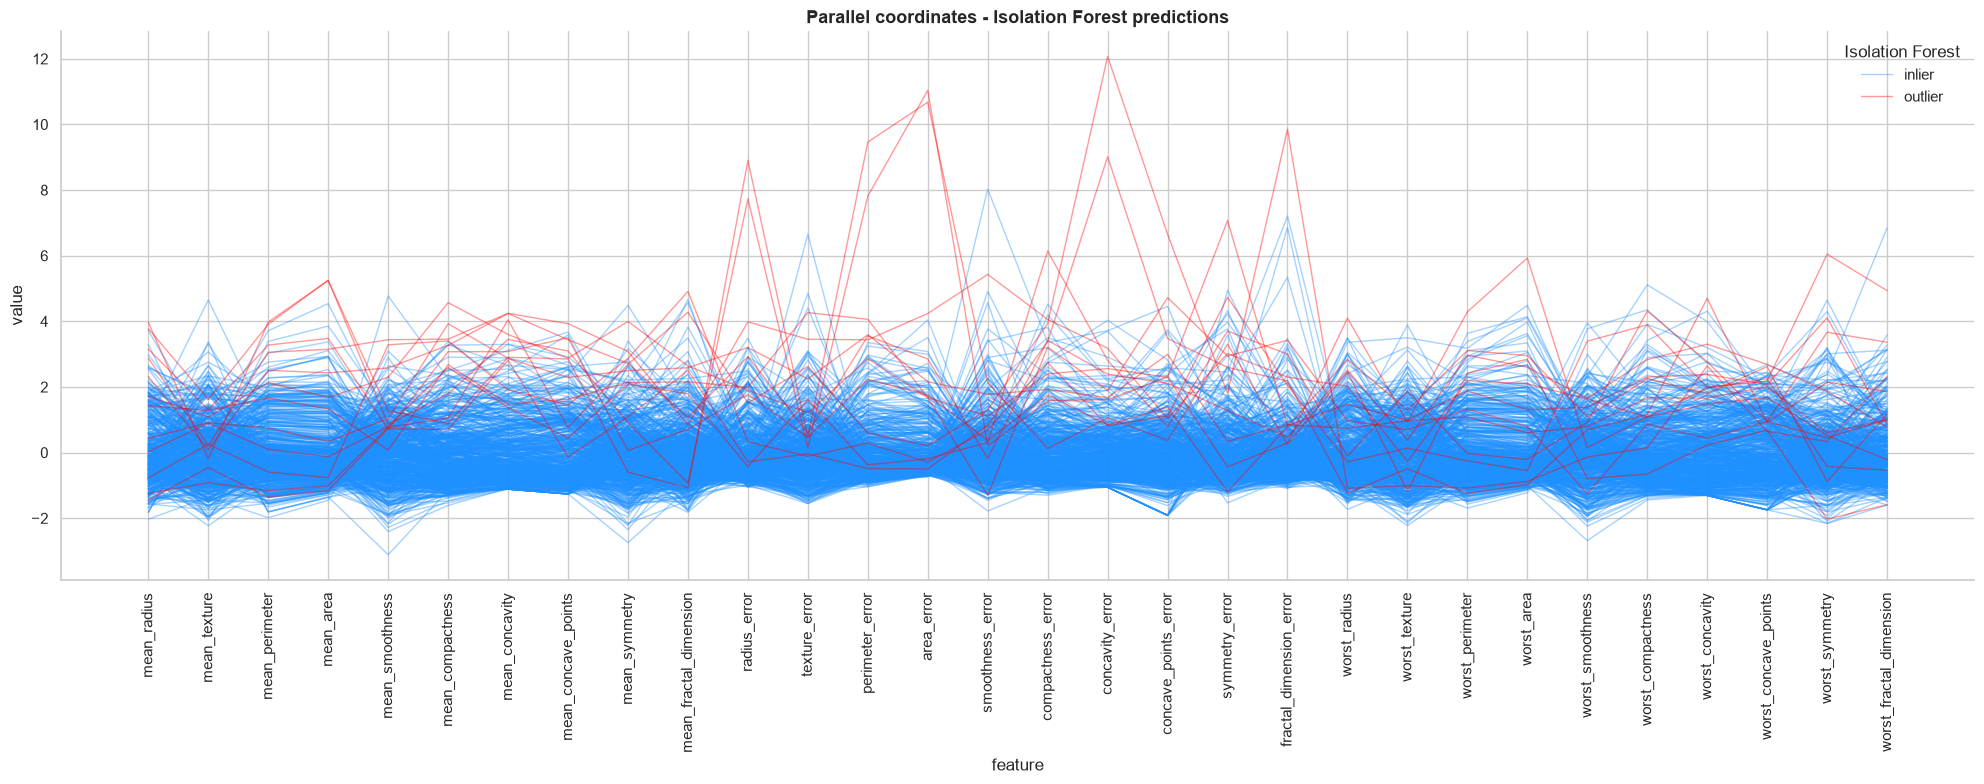

In [28]:
df_plot = df_scaled.copy()
df_plot["record_id"] = df_plot.index
df_plot['isolation_prediction'] = isolation_predictions
df_plot['isolation_prediction'] = df_plot['isolation_prediction'].map({1: 'inlier', -1: 'outlier'})

df_melted = df_plot.melt(
    id_vars=["record_id", "isolation_prediction"],
    value_vars=features,
    var_name="feature",
    value_name="value",
)

fig, ax = plt.subplots(figsize=(20, 8))

sns.lineplot(
    data=df_melted,
    x="feature", y="value",
    hue="isolation_prediction",
    units="record_id", estimator=None,
    palette=["dodgerblue", "red"],
    alpha=0.4, linewidth=1,
    ax=ax,
)

ax.tick_params(axis="x", labelrotation=90)
ax.set_title("Parallel coordinates - Isolation Forest predictions", fontsize=13, fontweight="bold")
ax.legend(title="Isolation Forest", frameon=False)
sns.despine(ax=ax)

fig.tight_layout()
plt.show(fig)
plt.close(fig)

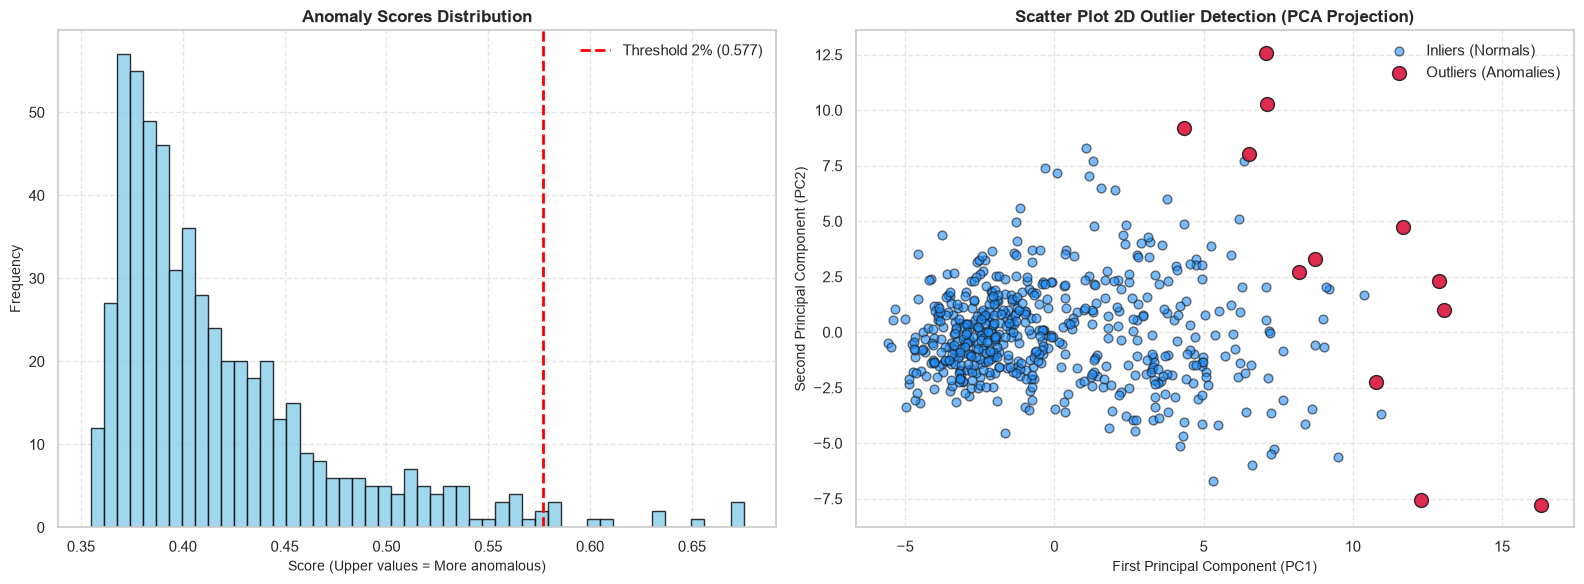

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(isolation_scores, bins=50, color='skyblue', edgecolor='black', alpha=0.8)
axes[0].axvline(x=threshold_score, color='red', linestyle='--', linewidth=2, label=f'Threshold 2% ({threshold_score:.3f})')
axes[0].set_title('Anomaly Scores Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Score (Upper values = More anomalous)', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].scatter(
    df_pca[isolation_predictions == 1, 0], df_pca[isolation_predictions == 1, 1],
    c='dodgerblue', label='Inliers (Normals)', alpha=0.6, edgecolors='k', s=40
)
axes[1].scatter(
    df_pca[isolation_predictions == -1, 0], df_pca[isolation_predictions == -1, 1],
    c='crimson', label='Outliers (Anomalies)', alpha=0.9, edgecolors='k', s=100, marker='o'
)

axes[1].set_title('Scatter Plot 2D Outlier Detection (PCA Projection)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('First Principal Component (PC1)', fontsize=10)
axes[1].set_ylabel('Second Principal Component (PC2)', fontsize=10)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [30]:
from umap import UMAP

reducer = UMAP(random_state=42, n_components=2, n_jobs=1)
reducer.fit_transform(df_scaled)
umap_df = pd.DataFrame(reducer.embedding_)
umap_df['diagnosis'] = df['diagnosis']
umap_df.head()

,0,1,diagnosis
0,3.261313,5.476377,Malignant
1,3.649797,7.306175,Malignant
2,3.377698,5.931309,Malignant
3,5.478472,5.204864,Malignant
4,2.898614,7.331754,Malignant


Text(0.5, 1.0, 'UMAP Projection')

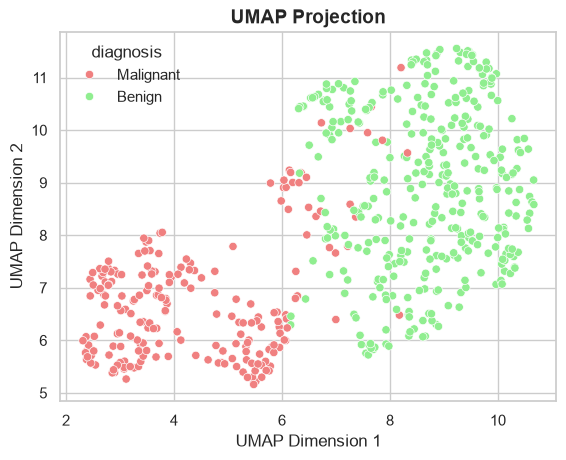

In [31]:
sns.scatterplot(data=umap_df, x=0, y=1, hue="diagnosis", palette=DIAGNOSIS_PALETTE)
plt.xlabel("UMAP Dimension 1", fontsize=12)
plt.ylabel("UMAP Dimension 2", fontsize=12)
plt.title("UMAP Projection", fontsize=14, fontweight="bold")

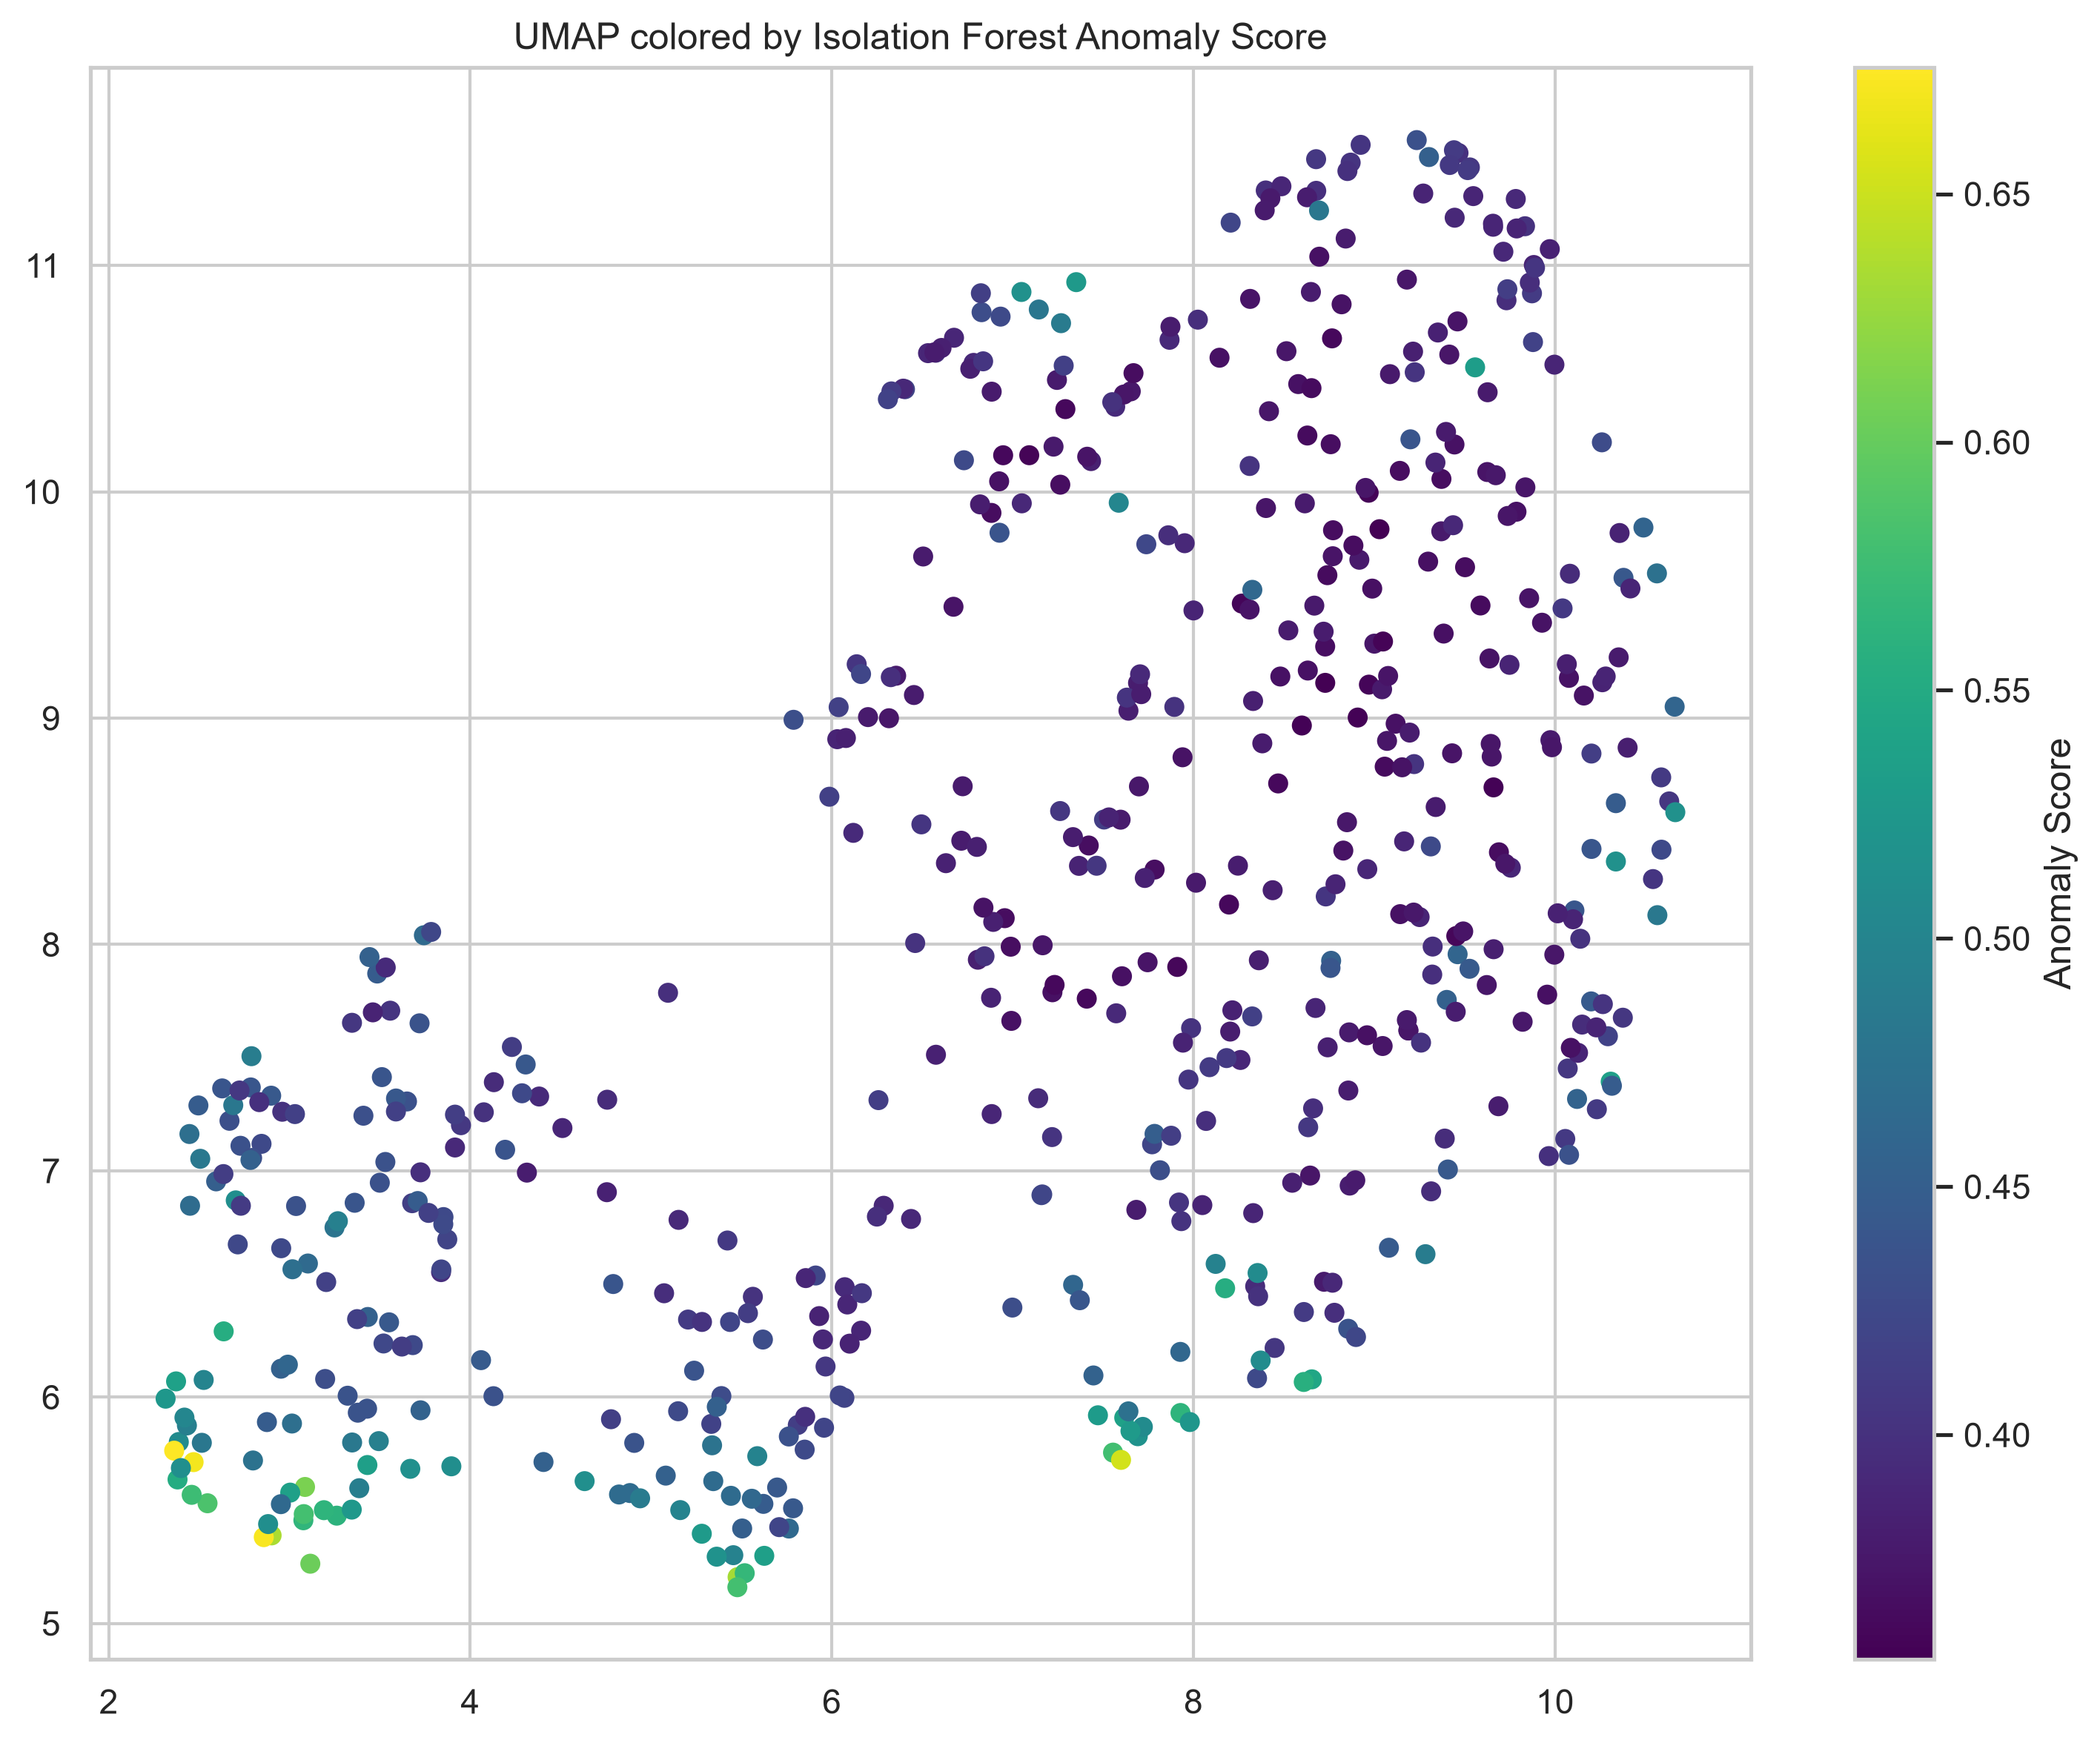

In [32]:
plot_df = umap_df.copy()
plot_df['anomaly_score'] = isolation_scores

fig, ax = plt.subplots(1, 1, figsize=(10, 8), dpi=300)

scatter = ax.scatter(
    plot_df[0], plot_df[1],
    c=plot_df['anomaly_score'], cmap='viridis',
    s=30
)

ax.set_title('UMAP colored by Isolation Forest Anomaly Score')
fig.colorbar(scatter, ax=ax, label='Anomaly Score')

fig.tight_layout()
plt.show()

In [33]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = df[features]
vif_data = sm.add_constant(vif_data)

vif_df = pd.DataFrame({
    "features": vif_data.columns.to_list()
})
vif_df['vif'] = [variance_inflation_factor(vif_data.values, i)
                  for i in range(vif_data.shape[1])]


conditions = [
    vif_df['vif'] < 5,
    (vif_df['vif'] >= 5) & (vif_df['vif'] < 15),
    vif_df['vif'] >= 15
]
condition_meaning = ['not significant', 'moderate', 'severe']


vif_df['multicollinearity'] = np.select(conditions, condition_meaning, default='unkown')


vif_df = vif_df[vif_df['features'] != 'const'].sort_values(ascending=False, by='vif')

vif_df

,features,vif,multicollinearity
1,mean_radius,3806.115296,severe
3,mean_perimeter,3786.400419,severe
21,worst_radius,799.105946,severe
23,worst_perimeter,405.023336,severe
4,mean_area,347.878657,severe
24,worst_area,337.221924,severe
11,radius_error,75.462027,severe
7,mean_concavity,70.767720,severe
13,perimeter_error,70.359695,severe
8,mean_concave_points,60.041733,severe


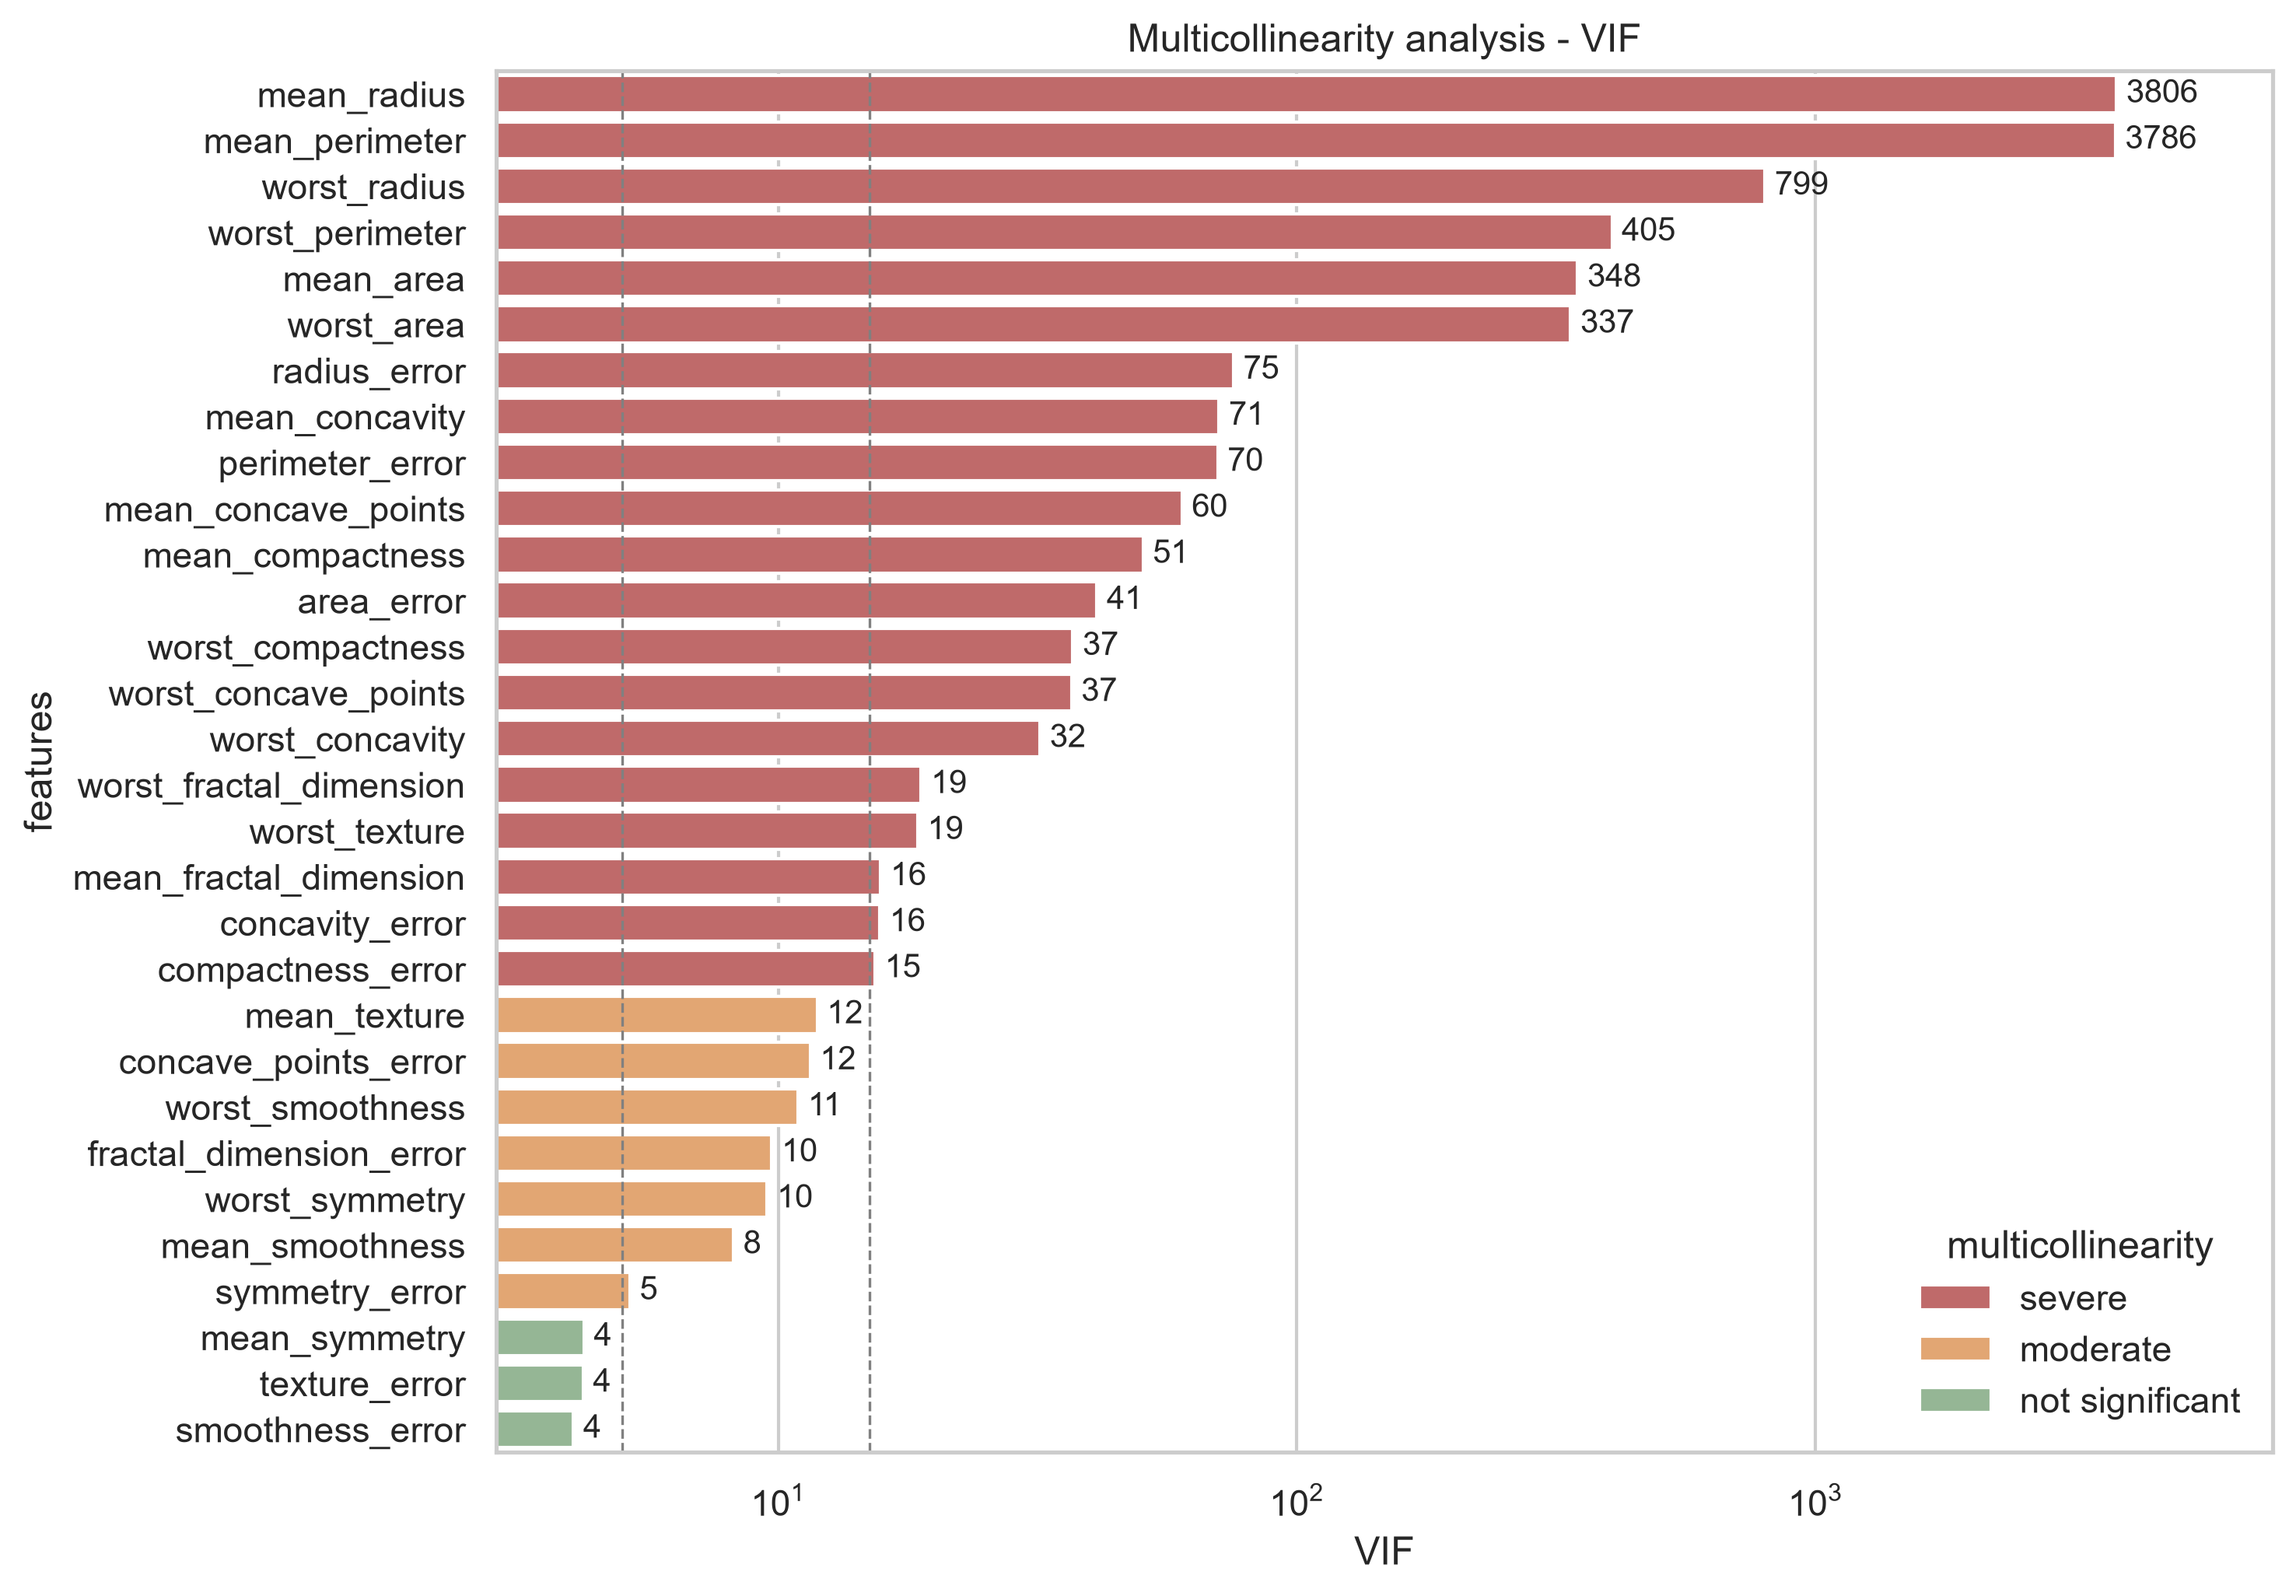

In [34]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7), dpi=300)

multicollinearity_palette = {
    "severe": "indianred",
    "moderate": "sandybrown",
    "not significant": "darkseagreen"
}

sns.set_style("whitegrid")

sns.barplot(
    data=vif_df,
    x='vif',
    y='features',
    hue='multicollinearity',
    palette=multicollinearity_palette,
    ax=ax,
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=10, padding=3) #type: ignore


ax.set_xscale('log')
ax.set_xlim(right=vif_df['vif'].max() * 2)

ax.axvline(5, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(15, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('VIF')


ax.set_title("Multicollinearity analysis - VIF")
fig.tight_layout()
plt.show(fig)